<link href="https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700&display=swap" rel="stylesheet">

<div style="background-color:#023047; padding: 2rem; border-radius: 1rem; color: white; font-family: 'Poppins', sans-serif;">

  <h1 style="color: #FFB701; font-size: 2.5rem; text-align: center; font-weight: 700;">
    Fighting the Silent Epidemic
  </h1>

  <h2 style="color: #FC8500; text-align: center; font-size: 1.5rem; font-weight: 600;">
    Machine Learning on the Frontlines of Predicting NCD Mortality and Unmasking Its Key Drivers
  </h2>

  <hr style="border: 1px solid #209EBB; width: 80%; margin: 2rem auto;">

  <p style="color: #BECAE6; font-size: 1.1rem; text-align: center;">
    A Final Requirement for DS322: Machine Learning
  </p>

  <p style="color: #BECAE6; font-size: 1.1rem; text-align: center;">
    <strong>Authors:</strong> Casino, Gamali, Felisilda, Menorias, Nanay<br>
    <strong>Instructor:</strong> Matthew Real Maulion
  </p>

</div>

## **1 Executive Summary**

This study utilized machine learning methodologies to forecast global non-communicable disease (NCD) mortality rates based on a comprehensive set of behavioral and metabolic health indicators. Given that NCDs remain the leading causes of death worldwide despite their preventability, the primary aim was to assess the predictive accuracy of data-driven models and identify the most influential risk factors across diverse populations.

The analysis involved training and testing various machine learning regression models, including linear approaches, tree-based ensembles (such as XGBoost, Gradient Boosting, Random Forest, and Decision Tree), and the K-Nearest Neighbors (KNN) algorithm. Non-linear models consistently demonstrated superior performance over linear methods, with tree-based ensembles achieving high predictive accuracy, indicated by Test R² values exceeding 0.99. Notably, the KNN model, after hyperparameter optimization to an optimal K=3, exhibited exceptional predictive accuracy (Test R² = 0.9999) and robust performance even when subjected to data noise, underscoring its strong applicability for real-world health scenarios.

Feature importance analysis, using SHAP values for the KNN model, revealed key predictors of NCD mortality. Factors significantly associated with increased mortality included living in the Americas region, elevated levels of non-HDL cholesterol, high smoking prevalence, increased consumption of spirits, and a higher prevalence of diabetes. Conversely, high levels of HDL cholesterol were identified as a substantial protective factor, correlating with lower predicted mortality. Temporal trends over years also contributed to the predictions.

Intriguing and complex relationships were observed for body mass index (BMI) indicators: a lower prevalence of overweight and obesity unexpectedly correlated with higher predicted mortality, while the influence of underweight prevalence on mortality was varied and context-dependent. Furthermore, insufficient physical activity among both adolescents and adults showed a generally positive, though less pronounced, contribution to predicted mortality.

These findings highlight the efficacy of non-parametric models like KNN for NCD mortality forecasting. By illuminating both well-established and nuanced risk factor relationships, this research offers actionable insights for developing data-driven NCD prevention strategies and enhancing global health surveillance.

## **2 Introduction**

Noncommunicable diseases (NCDs), including cardiovascular diseases, cancers, chronic respiratory diseases, and diabetes, are the leading cause of mortality globally, accounting for approximately 74% of all deaths (World Health Organization [WHO], 2023). Unlike communicable diseases, which can often be prevented or controlled through vaccination and containment measures, NCDs develop gradually due to a combination of genetic and behavioral risk factors.

The growing prevalence of NCDs poses a significant threat to global health, contributing not only to high mortality rates but also to reduced workforce productivity and increased healthcare costs. These challenges place considerable strain on health systems worldwide (Bloom et al., 2011; Chaker et al., 2015).

While many NCDs are preventable through early detection and modification of risk behaviors, a critical limitation remains: the lack of scalable and accurate tools for effective risk stratification and early prediction. This gap often leads to reactive healthcare strategies rather than proactive, preventive interventions, resulting in delayed diagnoses, increased treatment expenses, and poorer clinical outcomes (Alanazi, 2022).

Recent advancements in artificial intelligence, particularly machine learning (ML), offer promising opportunities to overcome these challenges. ML techniques have demonstrated strong potential in healthcare for uncovering complex patterns within large datasets, improving prognostic modeling, and enhancing clinical decision-making (Ko et al., 2023). By leveraging these approaches, it is possible to support population-level health planning and develop targeted intervention strategies.

This study applies regression-based ML models to forecast NCD mortality rates across multiple countries using a comprehensive dataset that includes behavioral and metabolic indicators. The objective is to develop predictive models that not only achieve high accuracy but also provide actionable insights to inform evidence-based policy, optimize resource allocation, and advance global efforts to reduce the burden of NCDs through anticipatory and preventive public health strategies.

### **2.1 Significance of the Study**
This study addresses the growing challenge of noncommunicable diseases (NCDs) by applying machine learning to predict NCD mortality using global health indicators. This approach offers new opportunities for early detection and prevention across diverse populations.

The findings aim to assist policymakers and healthcare planners in making informed, data-driven decisions. By identifying key risk factors such as tobacco use and obesity, the model supports the development of more targeted and efficient public health strategies.

Ultimately, this research contributes to global efforts to reduce NCD-related deaths, improve health outcomes, and promote equitable healthcare by transforming data into actionable insights.


## **3 Problem Statement**

What factors are driving the global rise in noncommunicable diseases (NCDs), which remain the leading cause of death worldwide despite being largely preventable? How do behavioral risks such as tobacco use, physical inactivity, and harmful alcohol consumption, along with metabolic conditions like obesity, diabetes, and high cholesterol, contribute to this ongoing public health crisis? Can machine learning models, particularly those based on regression, accurately forecast NCD mortality rates across different populations using such behavioral and metabolic data? Which of these indicators have the strongest predictive power, and to what extent can insights from these models support earlier identification of at-risk groups? 

### **3.1 Project Aim**

* To train a regression-based machine learning model using global health indicator data from the Humanitarian Data Exchange (HDX) to predict noncommunicable disease (NCD) mortality rates across countries.
* To identify and quantify the impact of key behavioral and metabolic risk factors such as tobacco use, physical inactivity, obesity, diabetes, and high cholesterol on NCD mortality outcomes.
* To uncover data-driven patterns that enable earlier identification of at-risk populations and to assess the model’s potential in supporting targeted, evidence-based public health strategies aimed at reducing the global burden of NCDs.



## **4 Methodology**


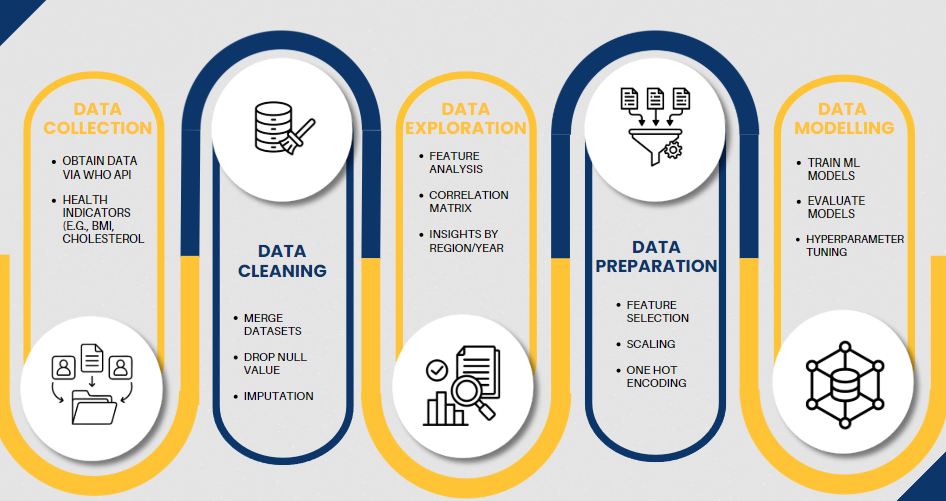

In [4]:
import warnings
warnings.filterwarnings("ignore")

import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    explained_variance_score,
    max_error
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd
import time
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    explained_variance_score, max_error
)

### **4.1 Data Collection**

The dataset used in this study was compiled by retrieving key indicators related to noncommunicable diseases (NCDs) from the World Health Organization (WHO) Global Health Observatory (GHO) API. Each indicator was selected based on the NCD-related metrics identified by the Humanitarian Data Exchange (HDX) and was programmatically retrieved and stored in CSV format for further analysis.

The dataset includes multi-year data across various countries, covering major NCD risk factors such as alcohol consumption, body mass index (BMI), cholesterol levels, and demographic variables. Structured in tabular form, it contains a mix of categorical and continuous variables, making it well-suited for statistical analysis and machine learning applications. These data provide a foundation for modeling and predicting NCD mortality rates associated with cardiovascular diseases, diabetes, cancer, and chronic respiratory conditions.

We selected a focused set of NCD indicators from HDX, each represented by a single dataset containing crude estimates only to ensure consistency, comparability, and interpretability. Crude values reflect observed population-level data without demographic adjustments, making them suitable for direct comparison across countries. We excluded age-standardized and redundant indicators to maintain a uniform data structure, avoid overlap, and simplify modeling. This careful curation balances data quality with analytical clarity, ensuring a reliable foundation for predictive analysis of NCD mortality and risk factors:

| **Indicator Code**              | **Category**                | **Indicator Name**                                                              |
|---------------------------------|-----------------------------|----------------------------------------------------------------------------------|
| M_est_cig_curr                  | Tobacco Use                 | Estimated prevalence of current cigarette smoking (%)                           |
| M_est_smk_curr                  | Tobacco Use                 | Estimated prevalence of current tobacco smoking (%)                             |
| M_est_tob_curr                  | Tobacco Use                 | Estimated prevalence of current tobacco use (%)                                 |
| NCD_BMI_18C                     | Obesity / Overweight        | Underweight among adults (BMI < 18.5) – crude                                    |
| NCD_BMI_25C                     | Obesity / Overweight        | Overweight among adults (BMI ≥ 25) – crude                                       |
| NCD_BMI_30C                     | Obesity / Overweight        | Obesity among adults (BMI ≥ 30) – crude                                          |
| NCD_CHOL_MEANHDL_C              | Cholesterol                 | Mean HDL cholesterol – crude                                                     |
| NCD_CHOL_MEANNONHDL_C           | Cholesterol                 | Mean non-HDL cholesterol – crude                                                 |
| NCD_CHOL_MEANTOTALCHOL_C        | Cholesterol                 | Mean total cholesterol – crude                                                   |
| NCD_DIABETES_PREVALENCE_CRUDE   | Diabetes                    | Prevalence of diabetes – crude                                                   |
| NCD_DTH_TOT                     | Mortality                   | Total number of deaths caused by NCDs                                            |
| NCD_PAA                         | Physical Activity           | Insufficient physical activity – age-standardized                                |
| NCD_PAC                         | Physical Activity           | Insufficient physical activity – crude                                           |
| NCD_PAC_ADO                     | Physical Activity           | Insufficient physical activity among adolescents                                 |
| SA_0000001400                   | Alcohol Use                 | Recorded alcohol consumption per capita (15+) in litres of pure alcohol         |


Each indicator is contained within a single dataset. A dataset consists of the following features:

| **Feature**             | **Data Type** | **Definition**                                                                 |
|-------------------------|---------------|---------------------------------------------------------------------------------|
| Id                      | int64         | Unique identifier for each record.                                             |
| IndicatorCode           | object        | Code representing a specific health indicator.                                |
| SpatialDimType          | object        | Type of spatial dimension (e.g., country, region).                            |
| SpatialDim              | object        | Spatial identifier (e.g., country code).                                       |
| ParentLocationCode      | object        | Code for the parent location (e.g., continent code).                          |
| TimeDimType             | object        | Type of time dimension (e.g., year).                                          |
| ParentLocation          | object        | Name of the parent location (e.g., continent).                                |
| Dim1Type                | object        | Type of the first dimension (e.g., age, gender).                              |
| TimeDim                 | int64         | Year of the data record.                                                      |
| Dim1                    | object        | First dimension value (e.g., male, female).                                   |
| Dim2Type                | object        | Type of the second dimension (optional).                                      |
| Dim2                    | object        | Second dimension value (optional).                                            |
| Dim3Type                | float64       | Type of the third dimension (not used, all nulls).                            |
| Dim3                    | float64       | Third dimension value (not used, all nulls).                                  |
| DataSourceDimType       | object        | Type of data source dimension (optional).                                     |
| DataSourceDim           | object        | Data source identifier (optional).                                            |
| Value                   | object        | Raw value (may include strings, numbers, or symbols).                         |
| NumericValue            | float64       | Numeric representation of the Value.                                          |
| Low                     | float64       | Lower bound of the confidence interval.                                       |
| High                    | float64       | Upper bound of the confidence interval.                                       |
| Comments                | object        | Additional notes or comments on the data.                                     |
| Date                    | object        | Full date associated with the data record.                                    |
| TimeDimensionValue      | int64         | Duplicate of TimeDim or used similarly.                                       |
| TimeDimensionBegin      | object        | Start of the time dimension range.                                            |
| TimeDimensionEnd        | object        | End of the time dimension range.                                              |
| GHO_DisplayName         | object        | Display name for the Global Health Observatory indicator.                     |
| GHO_Code                | object        | Code for the Global Health Observatory indicator.                             |


**Country Mapping**

This script retrieves a comprehensive list of countries available in the World Health Organization (WHO) Global Health Observatory (GHO) API. By querying the Dimension/COUNTRY/DimensionValues endpoint, it extracts country names along with their corresponding WHO country codes.

The script outputs the country names in a human-readable format (Country Name (Code)) and returns a dictionary mapping each country name to its code. This mapping is useful for programmatically accessing country-specific health data from the GHO API in subsequent data retrieval and analysis tasks.

In [19]:
"""

# Country Mapping
# This script fetches a list of available countries from the GHO API and prints them in a readable format.

import requests

def list_available_countries():
    url = "https://ghoapi.azureedge.net/api/Dimension/COUNTRY/DimensionValues"
    response = requests.get(url)
    country_data = response.json()["value"]

    countries = {item["Title"]: item["Code"] for item in country_data}
    for name, code in countries.items():
        print(f"{name} ({code})")

    return countries

# Retrieve list of data
list_available_countries()

"""

'\n\n# Country Mapping\n# This script fetches a list of available countries from the GHO API and prints them in a readable format.\n\nimport requests\n\ndef list_available_countries():\n    url = "https://ghoapi.azureedge.net/api/Dimension/COUNTRY/DimensionValues"\n    response = requests.get(url)\n    country_data = response.json()["value"]\n\n    countries = {item["Title"]: item["Code"] for item in country_data}\n    for name, code in countries.items():\n        print(f"{name} ({code})")\n\n    return countries\n\n# Retrieve list of data\nlist_available_countries()\n\n'

**GHO Indicators Mapping**

This Python script is designed to generate a mapping between WHO Global Health Observatory (GHO) indicator codes and their corresponding display names by processing a CSV file. The CSV file is expected to contain two key columns: 'GHO (CODE)' and 'GHO (DISPLAY)'. Using the pandas library to read the file and a defaultdict from the collections module, the script iterates through each row to group all unique display labels associated with each GHO code. This is particularly useful in cases where a single indicator code may appear with multiple descriptive labels due to variations in data sources or formatting. To facilitate easier downstream use, the sets of display names are optionally converted into lists. Finally, the script prints a sample of the resulting dictionary in a readable format. This mapping is valuable for data cleaning, indicator standardization, and enhancing the interpretability of WHO GHO datasets in analytical workflows.

In [20]:
"""

# Extract GHO Code to GHO Display Mapping
# This script reads a CSV file containing GHO codes and displays, and creates a mapping of GHO codes to their corresponding displays.

import pandas as pd
from collections import defaultdict

# Step 1: Load your CSV
df = pd.read_csv('sample.csv')  # replace with your real file

# Step 2: Group GHO Code to ALL corresponding GHO Displays
gho_mapping = defaultdict(set)  # use a set to avoid repeated identical displays

for idx, row in df.iterrows():
    code = row['GHO (CODE)']
    display = row['GHO (DISPLAY)']
    gho_mapping[code].add(display)

# Step 3: (Optional) Convert sets to lists for easier use later
gho_mapping = {code: list(displays) for code, displays in gho_mapping.items()}

# Step 4: View results
print("Sample GHO Mapping:")
for code, displays in list(gho_mapping.items()):
    print(f"{code}: {displays}")

"""

'\n\n# Extract GHO Code to GHO Display Mapping\n# This script reads a CSV file containing GHO codes and displays, and creates a mapping of GHO codes to their corresponding displays.\n\nimport pandas as pd\nfrom collections import defaultdict\n\n# Step 1: Load your CSV\ndf = pd.read_csv(\'sample.csv\')  # replace with your real file\n\n# Step 2: Group GHO Code to ALL corresponding GHO Displays\ngho_mapping = defaultdict(set)  # use a set to avoid repeated identical displays\n\nfor idx, row in df.iterrows():\n    code = row[\'GHO (CODE)\']\n    display = row[\'GHO (DISPLAY)\']\n    gho_mapping[code].add(display)\n\n# Step 3: (Optional) Convert sets to lists for easier use later\ngho_mapping = {code: list(displays) for code, displays in gho_mapping.items()}\n\n# Step 4: View results\nprint("Sample GHO Mapping:")\nfor code, displays in list(gho_mapping.items()):\n    print(f"{code}: {displays}")\n\n'

**Fetch Datasets**

This code automates the retrieval of health indicator data from the WHO Global Health Observatory (GHO) API and stores the results in CSV format. Specifically, it takes a dictionary of GHO indicator codes and their corresponding display names (`gho_mapping`) and iteratively queries the GHO API to fetch all available data for each code. The script uses the `requests` library to handle API communication and includes error handling to manage potential request failures or network issues. For each indicator, the retrieved data is enriched with the original GHO code and its display name for traceability, then saved as a CSV file within a designated output folder. The process includes a short delay between requests to avoid overloading the API. 


In [21]:
"""
# Fetch Data from WHO GHO API
# This script fetches data from the WHO GHO API for a given GHO code and saves it to a CSV file.
import requests
import pandas as pd
import os
import time

# WHO API base endpoint
WHO_API_BASE = "https://ghoapi.azureedge.net/api/"

def fetch_indicator_data(gho_code):
    # Fetch all data for a specific GHO indicator (no country filtering).
    url = f"{WHO_API_BASE}{gho_code}"
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        return response.json().get("value", [])
    except requests.RequestException as e:
        print(f"Error fetching data for {gho_code}: {e}")
        return []

def fetch_all_indicators(gho_mapping, output_folder="gho_indicator_data"):
    # Fetch and save all data for each GHO indicator in the mapping.
    os.makedirs(output_folder, exist_ok=True)

    for gho_code, display_name in gho_mapping.items():
        print(f"\nFetching GHO Indicator: {gho_code} - {display_name}")
        records = fetch_indicator_data(gho_code)

        if records:
            for rec in records:
                rec["GHO_DisplayName"] = display_name
                rec["GHO_Code"] = gho_code

            df = pd.DataFrame(records)
            filename = os.path.join(output_folder, f"{gho_code}.csv")
            try:
                df.to_csv(filename, index=False)
                print(f"Saved {len(df)} records to {filename}")
            except PermissionError as e:
                print(f"Permission error saving file {filename}: {e}")
        else:
            print(f"No data found for {gho_code}")
        
        time.sleep(0.5)  

# fetch all indicators
fetch_all_indicators(gho_mapping)
"""


'\n# Fetch Data from WHO GHO API\n# This script fetches data from the WHO GHO API for a given GHO code and saves it to a CSV file.\nimport requests\nimport pandas as pd\nimport os\nimport time\n\n# WHO API base endpoint\nWHO_API_BASE = "https://ghoapi.azureedge.net/api/"\n\ndef fetch_indicator_data(gho_code):\n    # Fetch all data for a specific GHO indicator (no country filtering).\n    url = f"{WHO_API_BASE}{gho_code}"\n    try:\n        response = requests.get(url, timeout=30)\n        response.raise_for_status()\n        return response.json().get("value", [])\n    except requests.RequestException as e:\n        print(f"Error fetching data for {gho_code}: {e}")\n        return []\n\ndef fetch_all_indicators(gho_mapping, output_folder="gho_indicator_data"):\n    # Fetch and save all data for each GHO indicator in the mapping.\n    os.makedirs(output_folder, exist_ok=True)\n\n    for gho_code, display_name in gho_mapping.items():\n        print(f"\nFetching GHO Indicator: {gho_code} 

### **4.2 Data Cleaning**

**Merge Datasets**

This script merges multiple CSV files, each containing a different WHO GHO indicator, into a single dataset. It reads all files from a specified directory, adds an optional source file column for traceability, concatenates them into one DataFrame, and saves the result as a unified CSV for further analysis.

In [2]:
# Step 1: Define the directory containing GHO indicator CSVs
data_dir = "gho_indicator_data"

# Step 2: Get a list of all CSV file paths in the directory
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))

# Step 3: Load each CSV into a separate DataFrame and filter by TimeDim <= 2024
dataframes = []
for file_path in csv_files:
    df = pd.read_csv(file_path)
    # Ensure 'TimeDim' column exists and filter rows where TimeDim <= 2024
    if 'TimeDim' in df.columns:
        df = df[df['TimeDim'] <= 2024]
    else:
        print(f"Warning: 'TimeDim' column not found in {file_path}")
    df["source_file"] = os.path.basename(file_path)  # Optional: add source file info
    dataframes.append(df)

# Step 4: Merge all filtered DataFrames into a single DataFrame
merged_df = pd.concat(dataframes, ignore_index=True)

# Step 5: Save the merged DataFrame to a CSV file
output_path = "merged_gho_indicators_filtered.csv"
merged_df.to_csv(output_path, index=False)

print(f"Merged {len(csv_files)} files into {output_path} with TimeDim <= 2024")


NameError: name 'glob' is not defined

In [5]:
df = pd.read_csv("merged_gho_indicators_filtered.csv")
# Display the first few rows of the merged DataFrame
df.head()

,Id,IndicatorCode,SpatialDimType,SpatialDim,ParentLocationCode,TimeDimType,ParentLocation,Dim1Type,TimeDim,Dim1,...,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd,GHO_DisplayName,GHO_Code,source_file
0,44,M_Est_cig_curr,COUNTRY,CZE,EUR,YEAR,Europe,SEX,2007,SEX_FMLE,...,18.0,25.6,NaN,2024-01-16T16:52:44+01:00,2007,2007-01-01T00:00:00+01:00,2007-12-31T00:00:00+01:00,['Estimate of current cigarette smoking preval...,M_Est_cig_curr,M_Est_cig_curr.csv
1,2830,M_Est_cig_curr,COUNTRY,USA,AMR,YEAR,Americas,SEX,2007,SEX_FMLE,...,15.4,21.5,NaN,2024-01-16T16:52:46+01:00,2007,2007-01-01T00:00:00+01:00,2007-12-31T00:00:00+01:00,['Estimate of current cigarette smoking preval...,M_Est_cig_curr,M_Est_cig_curr.csv
2,3751,M_Est_cig_curr,COUNTRY,CZE,EUR,YEAR,Europe,SEX,2020,SEX_MLE,...,21.5,33.9,NaN,2024-01-16T16:52:56+01:00,2020,2020-01-01T00:00:00+01:00,2020-12-31T00:00:00+01:00,['Estimate of current cigarette smoking preval...,M_Est_cig_curr,M_Est_cig_curr.csv
3,6752,M_Est_cig_curr,COUNTRY,BRB,AMR,YEAR,Americas,SEX,2021,SEX_BTSX,...,3.0,7.6,The most recent survey was conducted in 2011-1...,2024-01-16T16:53:07+01:00,2021,2021-01-01T00:00:00+01:00,2021-12-31T00:00:00+01:00,['Estimate of current cigarette smoking preval...,M_Est_cig_curr,M_Est_cig_curr.csv
4,9035,M_Est_cig_curr,COUNTRY,PNG,WPR,YEAR,Western Pacific,SEX,2005,SEX_MLE,...,31.6,63.8,NaN,2024-01-16T16:52:30+01:00,2005,2005-01-01T00:00:00+01:00,2005-12-31T00:00:00+01:00,['Estimate of current cigarette smoking preval...,M_Est_cig_curr,M_Est_cig_curr.csv


In [7]:
# Display Column names
print("Column names in the merged DataFrame:")
print(df.columns.tolist())
# Display the number of rows and columns in the merged DataFrame
print("Number of rows and columns in the merged DataFrame:")
print(df.shape)

Column names in the merged DataFrame:
['Id', 'IndicatorCode', 'SpatialDimType', 'SpatialDim', 'ParentLocationCode', 'TimeDimType', 'ParentLocation', 'Dim1Type', 'TimeDim', 'Dim1', 'Dim2Type', 'Dim2', 'Dim3Type', 'Dim3', 'DataSourceDimType', 'DataSourceDim', 'Value', 'NumericValue', 'Low', 'High', 'Comments', 'Date', 'TimeDimensionValue', 'TimeDimensionBegin', 'TimeDimensionEnd', 'GHO_DisplayName', 'GHO_Code', 'source_file']
Number of rows and columns in the merged DataFrame:
(284115, 28)


**Null Values**

In [8]:
# Display null values in the merged DataFrame
print("Null values in the merged DataFrame:")
print(df.isnull().sum())

Null values in the merged DataFrame:
Id                         0
IndicatorCode              0
SpatialDimType             0
SpatialDim                 0
ParentLocationCode     12078
TimeDimType                0
ParentLocation         12078
Dim1Type                   0
TimeDim                    0
Dim1                       0
Dim2Type              131706
Dim2                  131706
Dim3Type              284115
Dim3                  284115
DataSourceDimType     235191
DataSourceDim         235191
Value                      0
NumericValue             183
Low                    48967
High                   48967
Comments              278673
Date                       0
TimeDimensionValue         0
TimeDimensionBegin         0
TimeDimensionEnd           0
GHO_DisplayName            0
GHO_Code                   0
source_file                0
dtype: int64


**Select Columns**

This code snippet extracts a subset of key columns from a larger health dataset to create a more manageable DataFrame for analysis. The selected columns include the indicator name and code (`GHO_DisplayName`, `GHO_Code`), geographic information (`ParentLocation`, `SpatialDim`), a disaggregation category (`Dim1`), the time dimension (`TimeDimensionValue`), and the actual numerical value of the indicator (`NumericValue`). These columns are chosen to focus on essential aspects of the data—what the indicator measures, where and when it applies, and its value—facilitating easier filtering, analysis, and modeling.


In [9]:
# Column selection for the merged DataFrame
selected_columns = [
    'GHO_DisplayName', 'GHO_Code', 'ParentLocation', 'SpatialDim', 'Dim1', 
    'TimeDimensionValue', 'NumericValue'
]
df_selected = df[selected_columns]
# Display the first few rows of the selected columns DataFrame
print("First few rows of the selected columns DataFrame:")
df_selected.head()

First few rows of the selected columns DataFrame:


,GHO_DisplayName,GHO_Code,ParentLocation,SpatialDim,Dim1,TimeDimensionValue,NumericValue
0,['Estimate of current cigarette smoking preval...,M_Est_cig_curr,Europe,CZE,SEX_FMLE,2007,21.8
1,['Estimate of current cigarette smoking preval...,M_Est_cig_curr,Americas,USA,SEX_FMLE,2007,18.5
2,['Estimate of current cigarette smoking preval...,M_Est_cig_curr,Europe,CZE,SEX_MLE,2020,27.7
3,['Estimate of current cigarette smoking preval...,M_Est_cig_curr,Americas,BRB,SEX_BTSX,2021,5.3
4,['Estimate of current cigarette smoking preval...,M_Est_cig_curr,Western Pacific,PNG,SEX_MLE,2005,47.7


**Indicator Columns**

This function reshapes the dataset into a wide format where each unique combination of health indicator and demographic category (e.g., sex) becomes its own column. It first combines the `GHO_Code` and `Dim1` columns to create a new column identifier (`GHO_Dim1`) representing specific indicator-category pairs. Then, it pivots the data so that each row corresponds to a country (`SpatialDim`), region (`ParentLocation`), and year (`TimeDimensionValue`), with separate columns for each indicator. The result is a clean, analysis-ready DataFrame where indicators are explicit and easily accessible for modeling or visualization.


In [10]:
def pivot_combined_sex_df(df_selected):
    # Make a copy to safely modify
    df_copy = df_selected.copy()
    
    # Combine GHO_Code and Dim1 into one column for wide-format pivoting
    df_copy["GHO_Dim1"] = df_copy["GHO_Code"] + "_" + df_copy["Dim1"]
    
    # Select relevant columns for pivoting
    df_pivot = df_copy[["SpatialDim", "ParentLocation", "TimeDimensionValue", "GHO_Dim1", "NumericValue"]]
    
    # Pivot to wide format
    df_wide = df_pivot.pivot_table(
        index=["SpatialDim", "ParentLocation", "TimeDimensionValue"],
        columns="GHO_Dim1",
        values="NumericValue"
    ).reset_index()
    
    df_wide.columns.name = None  # Remove the columns name set by pivot
    return df_wide

# Display the first few rows of the cleaned DataFrame
df_wide = pivot_combined_sex_df(df_selected)

In [11]:
# Display Column names
print("Column names in the merged DataFrame:")
df_wide.columns.tolist()

Column names in the merged DataFrame:


['SpatialDim',
 'ParentLocation',
 'TimeDimensionValue',
 'M_Est_cig_curr_SEX_BTSX',
 'M_Est_cig_curr_SEX_FMLE',
 'M_Est_cig_curr_SEX_MLE',
 'M_Est_smk_curr_SEX_BTSX',
 'M_Est_smk_curr_SEX_FMLE',
 'M_Est_smk_curr_SEX_MLE',
 'M_Est_tob_curr_SEX_BTSX',
 'M_Est_tob_curr_SEX_FMLE',
 'M_Est_tob_curr_SEX_MLE',
 'NCD_BMI_18C_SEX_BTSX',
 'NCD_BMI_18C_SEX_FMLE',
 'NCD_BMI_18C_SEX_MLE',
 'NCD_BMI_25C_SEX_BTSX',
 'NCD_BMI_25C_SEX_FMLE',
 'NCD_BMI_25C_SEX_MLE',
 'NCD_BMI_30C_SEX_BTSX',
 'NCD_BMI_30C_SEX_FMLE',
 'NCD_BMI_30C_SEX_MLE',
 'NCD_CHOL_MEANHDL_C_SEX_BTSX',
 'NCD_CHOL_MEANHDL_C_SEX_FMLE',
 'NCD_CHOL_MEANHDL_C_SEX_MLE',
 'NCD_CHOL_MEANNONHDL_C_SEX_BTSX',
 'NCD_CHOL_MEANNONHDL_C_SEX_FMLE',
 'NCD_CHOL_MEANNONHDL_C_SEX_MLE',
 'NCD_CHOL_MEANTOTALCHOL_C_SEX_BTSX',
 'NCD_CHOL_MEANTOTALCHOL_C_SEX_FMLE',
 'NCD_CHOL_MEANTOTALCHOL_C_SEX_MLE',
 'NCD_DIABETES_PREVALENCE_CRUDE_SEX_BTSX',
 'NCD_DIABETES_PREVALENCE_CRUDE_SEX_FMLE',
 'NCD_DIABETES_PREVALENCE_CRUDE_SEX_MLE',
 'NCD_DTH_TOT_SEX_BTSX',
 'NCD_D

**Assess Missingness**

This function calculates the percentage of missing data for each country across all available years and indicators in the wide-format dataset. It removes the year from the analysis to aggregate missingness at the country level, then counts how many data points are missing out of the total expected cells (based on the number of rows per country and the number of indicator columns). By dividing the number of missing values by the total expected values, it computes the percentage of missing data for each country. This provides a clear overview of data completeness and helps identify countries with significant gaps that may affect analysis or model reliability.


In [12]:
def missing_percentage_by_country_aggregated(df_wide):
    # Drop year to aggregate across all time
    df_grouped = df_wide.groupby("SpatialDim").agg(lambda x: x.isna().sum() if x.name not in ["ParentLocation"] else x.iloc[0])

    # Calculate number of relevant columns (excluding identifiers)
    data_columns = df_wide.drop(columns=["SpatialDim", "ParentLocation", "TimeDimensionValue"]).columns
    num_columns = len(data_columns)

    # Number of rows per country
    num_rows = df_wide.groupby("SpatialDim").size()

    # Total expected cells per country
    total_cells_per_country = num_rows * num_columns

    # Total missing values per country
    total_missing_per_country = df_wide.groupby("SpatialDim")[data_columns].apply(lambda x: x.isna().sum().sum())

    # Calculate percentage
    missing_percentage = (total_missing_per_country / total_cells_per_country * 100).reset_index(name="MissingPercentage")

    return missing_percentage

# Calculate and display results
missing_all = missing_percentage_by_country_aggregated(df_wide)

print("Missing Percentage by Country (aggregated) - All Sexes Combined:")
print(missing_all.sort_values("MissingPercentage", ascending=False).head(30))


Missing Percentage by Country (aggregated) - All Sexes Combined:
    SpatialDim  MissingPercentage
161        SMR          87.234043
7          ASM          74.468085
73         GRL          74.468085
23         BMU          74.468085
177        TKL          74.468085
149        PYF          74.468085
164        SSD          61.315280
148        PSE          61.315280
144        PRI          61.315280
63         GAB          58.373370
67         GIN          58.064516
129        NIC          57.721345
62         FSM          57.721345
1          AGO          57.721345
162        SOM          57.721345
96         KNA          57.687028
55         ERI          57.167771
30         CAF          57.103638
194        VUT          56.382979
192        VEN          56.108442
48         DJI          56.074125
172        SYR          56.074125
155        SDN          56.074125
121        MOZ          56.074125
102        LBY          56.074125
166        SUR          56.074125
111        MDG   

**Drop Countries with 70% missing data**

This function removes countries from the dataset that have more than 70% missing data across all indicators and years. It first calculates the percentage of missing values per country using the previously defined function. Then, it identifies countries exceeding the specified threshold and filters them out of the dataset. The result is a cleaned DataFrame (`df_wide_cleaned`) with only countries that have sufficient data for reliable analysis, helping to reduce noise and potential bias from incomplete records.



In [13]:
# 
def drop_high_missing_countries(df_wide, threshold=70.0):
    # Calculate missing percentage per country
    missing_pct = missing_percentage_by_country_aggregated(df_wide)
    
    # Identify countries with missing percentage > threshold
    countries_to_drop = missing_pct[missing_pct["MissingPercentage"] > threshold]["SpatialDim"].tolist()
    
    # Drop them from the DataFrame
    df_cleaned = df_wide[~df_wide["SpatialDim"].isin(countries_to_drop)]
    
    return df_cleaned, countries_to_drop

# Apply the drop function
df_wide_cleaned, dropped_countries = drop_high_missing_countries(df_wide, threshold=70.0)

print("Dropped countries with >70% missing data:")
print(dropped_countries)


Dropped countries with >70% missing data:
['ASM', 'BMU', 'GRL', 'PYF', 'SMR', 'TKL']


In [14]:
# null values in the cleaned DataFrame
print("Null values in the cleaned DataFrame:")
print(df_wide_cleaned.isnull().sum())
# Display the first few rows of the cleaned DataFrame
print("First few rows of the cleaned DataFrame:")
df_wide_cleaned.shape

Null values in the cleaned DataFrame:
SpatialDim                                       0
ParentLocation                                   0
TimeDimensionValue                               0
M_Est_cig_curr_SEX_BTSX                       9909
M_Est_cig_curr_SEX_FMLE                       9909
M_Est_cig_curr_SEX_MLE                        9909
M_Est_smk_curr_SEX_BTSX                       9909
M_Est_smk_curr_SEX_FMLE                       9909
M_Est_smk_curr_SEX_MLE                        9909
M_Est_tob_curr_SEX_BTSX                       9909
M_Est_tob_curr_SEX_FMLE                       9909
M_Est_tob_curr_SEX_MLE                        9909
NCD_BMI_18C_SEX_BTSX                          4827
NCD_BMI_18C_SEX_FMLE                          4827
NCD_BMI_18C_SEX_MLE                           4827
NCD_BMI_25C_SEX_BTSX                          4827
NCD_BMI_25C_SEX_FMLE                          4827
NCD_BMI_25C_SEX_MLE                           4827
NCD_BMI_30C_SEX_BTSX                        

(11229, 50)

**Imputation using Interpolation, Forward Fill and Backward Fill**

This code fills in missing indicator values in the cleaned dataset by applying a combination of linear interpolation, forward fill (`ffill`), and backward fill (`bfill`) within each country group. The process begins by sorting the data by country and year to maintain temporal order. Linear interpolation estimates missing values by assuming a gradual change over time, which is appropriate for time-series health data where values typically evolve smoothly. Forward and backward filling are used as backup methods to fill in any remaining gaps, especially at the start or end of a time series where interpolation alone cannot operate. This combined approach ensures that missing data is filled in a realistic, temporally consistent way while maximizing data completeness for subsequent modeling or analysis.


In [15]:
# Sorted and grouped by country
df_combined = df_wide_cleaned.sort_values(["SpatialDim", "TimeDimensionValue"])
meta_cols = ["SpatialDim", "ParentLocation", "TimeDimensionValue"]
data_cols = df_combined.columns.difference(meta_cols)

# Interpolate, then ffill and bfill
df_combined[data_cols] = (
    df_combined
    .groupby("SpatialDim")[data_cols]
    .apply(lambda group: (
        group.interpolate(method='linear', limit_direction='both')
             .ffill()
             .bfill()
    ))
    .reset_index(drop=True)
)

In [16]:
# Check for null values after interpolation
print("Null values after interpolation:")
print(df_combined.isnull().sum())

Null values after interpolation:
SpatialDim                                       0
ParentLocation                                   0
TimeDimensionValue                               0
M_Est_cig_curr_SEX_BTSX                       1692
M_Est_cig_curr_SEX_FMLE                       1692
M_Est_cig_curr_SEX_MLE                        1692
M_Est_smk_curr_SEX_BTSX                       1692
M_Est_smk_curr_SEX_FMLE                       1692
M_Est_smk_curr_SEX_MLE                        1692
M_Est_tob_curr_SEX_BTSX                       1692
M_Est_tob_curr_SEX_FMLE                       1692
M_Est_tob_curr_SEX_MLE                        1692
NCD_BMI_18C_SEX_BTSX                           188
NCD_BMI_18C_SEX_FMLE                           188
NCD_BMI_18C_SEX_MLE                            188
NCD_BMI_25C_SEX_BTSX                           188
NCD_BMI_25C_SEX_FMLE                           188
NCD_BMI_25C_SEX_MLE                            188
NCD_BMI_30C_SEX_BTSX                           18

**Drop Remain Missing Values**

After imputing missing values, checking and potentially dropping any remaining nulls ensures **data integrity** before modeling. Although most missing values are expected to be filled through interpolation and forward/backward filling, a few may still remain—particularly if a country's time series had no valid data points to begin with or if all values for a specific indicator were missing.

Earlier in the pipeline, countries with more than 70% missing data were dropped to eliminate low-quality entries. However, that still leaves partial gaps in otherwise useful countries, which are addressed through imputation. This final null check and optional drop step acts as a safeguard, ensuring no residual missing values persist that could break model training or evaluation, especially for algorithms that do not handle nulls natively.


In [17]:
# missing values remain
missing_summary = df_combined.isna().sum()
missing_summary = missing_summary[missing_summary > 0]

if missing_summary.empty:
    print("All missing values have been successfully imputed.")
else:
    print("Remaining missing values:")
    print(missing_summary)


Remaining missing values:
M_Est_cig_curr_SEX_BTSX                       1692
M_Est_cig_curr_SEX_FMLE                       1692
M_Est_cig_curr_SEX_MLE                        1692
M_Est_smk_curr_SEX_BTSX                       1692
M_Est_smk_curr_SEX_FMLE                       1692
M_Est_smk_curr_SEX_MLE                        1692
M_Est_tob_curr_SEX_BTSX                       1692
M_Est_tob_curr_SEX_FMLE                       1692
M_Est_tob_curr_SEX_MLE                        1692
NCD_BMI_18C_SEX_BTSX                           188
NCD_BMI_18C_SEX_FMLE                           188
NCD_BMI_18C_SEX_MLE                            188
NCD_BMI_25C_SEX_BTSX                           188
NCD_BMI_25C_SEX_FMLE                           188
NCD_BMI_25C_SEX_MLE                            188
NCD_BMI_30C_SEX_BTSX                           188
NCD_BMI_30C_SEX_FMLE                           188
NCD_BMI_30C_SEX_MLE                            188
NCD_CHOL_MEANHDL_C_SEX_BTSX                    281
NCD_C

In [18]:
# Identify metadata and data columns
meta_cols = ["SpatialDim", "ParentLocation", "TimeDimensionValue"]
data_cols = df_combined.columns.difference(meta_cols)

# Drop rows where any of the data columns have missing values
df_clean_final = df_combined.dropna(subset=data_cols)

# Confirm cleanup
print(f"Final cleaned dataset shape: {df_clean_final.shape}")
print(f"Remaining missing values: {df_clean_final.isna().sum().sum()}")


Final cleaned dataset shape: (6635, 50)
Remaining missing values: 0


In [19]:
# Rename metadata columns to user-friendly names
df_clean_final = df_clean_final.rename(columns={
    'SpatialDim': 'country',
    'ParentLocation': 'region',
    'TimeDimensionValue': 'year'
})

# Preview the new column names
print("Renamed key metadata columns:")
print([col for col in df_clean_final.columns if col in ['country', 'region', 'year']])

Renamed key metadata columns:
['country', 'region', 'year']


**Cleaned Dataset Ready for EDA**

| Variable                                | Description                                            |
|---------------------------------------|-------------------------------------------------------------------|
| country                               | Country name or code                                               |
| region                                | Geographic region                                                  |
| year                                  | Year of data collection                                           |
| M_Est_cig_curr_SEX_BTSX               | Estimated current cigarette use, sex combined (BTSX method)       |
| M_Est_cig_curr_SEX_FMLE               | Estimated current cigarette use, sex combined (FMLE method)       |
| M_Est_cig_curr_SEX_MLE                | Estimated current cigarette use, sex combined (MLE method)        |
| M_Est_smk_curr_SEX_BTSX               | Estimated current smoking prevalence, sex combined (BTSX)         |
| M_Est_smk_curr_SEX_FMLE               | Estimated current smoking prevalence, sex combined (FMLE)         |
| M_Est_smk_curr_SEX_MLE                | Estimated current smoking prevalence, sex combined (MLE)          |
| M_Est_tob_curr_SEX_BTSX               | Estimated current tobacco use, sex combined (BTSX)                 |
| M_Est_tob_curr_SEX_FMLE               | Estimated current tobacco use, sex combined (FMLE)                 |
| M_Est_tob_curr_SEX_MLE                | Estimated current tobacco use, sex combined (MLE)                  |
| NCD_BMI_18C_SEX_BTSX                  | Non-communicable disease BMI <18, sex combined (BTSX)             |
| NCD_BMI_18C_SEX_FMLE                  | Non-communicable disease BMI <18, sex combined (FMLE)             |
| NCD_BMI_18C_SEX_MLE                   | Non-communicable disease BMI <18, sex combined (MLE)              |
| NCD_BMI_25C_SEX_BTSX                  | NCD BMI ≥25, sex combined (BTSX)                                  |
| NCD_BMI_25C_SEX_FMLE                  | NCD BMI ≥25, sex combined (FMLE)                                  |
| NCD_BMI_25C_SEX_MLE                   | NCD BMI ≥25, sex combined (MLE)                                   |
| NCD_BMI_30C_SEX_BTSX                  | NCD BMI ≥30, sex combined (BTSX)                                  |
| NCD_BMI_30C_SEX_FMLE                  | NCD BMI ≥30, sex combined (FMLE)                                  |
| NCD_BMI_30C_SEX_MLE                   | NCD BMI ≥30, sex combined (MLE)                                   |
| NCD_CHOL_MEANHDL_C_SEX_BTSX           | Mean HDL cholesterol (mg/dL?), sex combined (BTSX)                |
| NCD_CHOL_MEANHDL_C_SEX_FMLE           | Mean HDL cholesterol, sex combined (FMLE)                         |
| NCD_CHOL_MEANHDL_C_SEX_MLE            | Mean HDL cholesterol, sex combined (MLE)                          |
| NCD_CHOL_MEANNONHDL_C_SEX_BTSX        | Mean non-HDL cholesterol, sex combined (BTSX)                     |
| NCD_CHOL_MEANNONHDL_C_SEX_FMLE        | Mean non-HDL cholesterol, sex combined (FMLE)                     |
| NCD_CHOL_MEANNONHDL_C_SEX_MLE         | Mean non-HDL cholesterol, sex combined (MLE)                      |
| NCD_CHOL_MEANTOTALCHOL_C_SEX_BTSX     | Mean total cholesterol, sex combined (BTSX)                       |
| NCD_CHOL_MEANTOTALCHOL_C_SEX_FMLE     | Mean total cholesterol, sex combined (FMLE)                       |
| NCD_CHOL_MEANTOTALCHOL_C_SEX_MLE      | Mean total cholesterol, sex combined (MLE)                        |
| NCD_DIABETES_PREVALENCE_CRUDE_SEX_BTSX | Crude diabetes prevalence, sex combined (BTSX)                  |
| NCD_DIABETES_PREVALENCE_CRUDE_SEX_FMLE | Crude diabetes prevalence, sex combined (FMLE)                  |
| NCD_DIABETES_PREVALENCE_CRUDE_SEX_MLE  | Crude diabetes prevalence, sex combined (MLE)                   |
| NCD_DTH_TOT_SEX_BTSX                  | Total NCD deaths, sex combined (BTSX)                             |
| NCD_DTH_TOT_SEX_FMLE                  | Total NCD deaths, sex combined (FMLE)                             |
| NCD_DTH_TOT_SEX_MLE                   | Total NCD deaths, sex combined (MLE)                              |
| NCD_PAA_SEX_BTSX                      | Physical activity adherence, sex combined (BTSX)                  |
| NCD_PAA_SEX_FMLE                      | Physical activity adherence, sex combined (FMLE)                  |
| NCD_PAA_SEX_MLE                       | Physical activity adherence, sex combined (MLE)                   |
| NCD_PAC_ADO_SEX_BTSX                  | Physical activity in adolescents, sex combined (BTSX)             |
| NCD_PAC_ADO_SEX_FMLE                  | Physical activity in adolescents, sex combined (FMLE)             |
| NCD_PAC_ADO_SEX_MLE                   | Physical activity in adolescents, sex combined (MLE)              |
| NCD_PAC_SEX_BTSX                     | Physical activity coverage, sex combined (BTSX)                    |
| NCD_PAC_SEX_FMLE                     | Physical activity coverage, sex combined (FMLE)                    |
| NCD_PAC_SEX_MLE                      | Physical activity coverage, sex combined (MLE)                     |
| SA_0000001400_ALCOHOLTYPE_SA_BEER     | Alcohol consumption from beer                                       |
| SA_0000001400_ALCOHOLTYPE_SA_OTHER_ALCOHOL | Alcohol consumption from other types                             |
| SA_0000001400_ALCOHOLTYPE_SA_SPIRITS  | Alcohol consumption from spirits                                   |
| SA_0000001400_ALCOHOLTYPE_SA_TOTAL    | Total alcohol consumption                                          |
| SA_0000001400_ALCOHOLTYPE_SA_WINE      | Alcohol consumption from wine                                      |


In [20]:
# Display Column names
print("Column names in the merged DataFrame:")
df_clean_final.columns.tolist()

Column names in the merged DataFrame:


['country',
 'region',
 'year',
 'M_Est_cig_curr_SEX_BTSX',
 'M_Est_cig_curr_SEX_FMLE',
 'M_Est_cig_curr_SEX_MLE',
 'M_Est_smk_curr_SEX_BTSX',
 'M_Est_smk_curr_SEX_FMLE',
 'M_Est_smk_curr_SEX_MLE',
 'M_Est_tob_curr_SEX_BTSX',
 'M_Est_tob_curr_SEX_FMLE',
 'M_Est_tob_curr_SEX_MLE',
 'NCD_BMI_18C_SEX_BTSX',
 'NCD_BMI_18C_SEX_FMLE',
 'NCD_BMI_18C_SEX_MLE',
 'NCD_BMI_25C_SEX_BTSX',
 'NCD_BMI_25C_SEX_FMLE',
 'NCD_BMI_25C_SEX_MLE',
 'NCD_BMI_30C_SEX_BTSX',
 'NCD_BMI_30C_SEX_FMLE',
 'NCD_BMI_30C_SEX_MLE',
 'NCD_CHOL_MEANHDL_C_SEX_BTSX',
 'NCD_CHOL_MEANHDL_C_SEX_FMLE',
 'NCD_CHOL_MEANHDL_C_SEX_MLE',
 'NCD_CHOL_MEANNONHDL_C_SEX_BTSX',
 'NCD_CHOL_MEANNONHDL_C_SEX_FMLE',
 'NCD_CHOL_MEANNONHDL_C_SEX_MLE',
 'NCD_CHOL_MEANTOTALCHOL_C_SEX_BTSX',
 'NCD_CHOL_MEANTOTALCHOL_C_SEX_FMLE',
 'NCD_CHOL_MEANTOTALCHOL_C_SEX_MLE',
 'NCD_DIABETES_PREVALENCE_CRUDE_SEX_BTSX',
 'NCD_DIABETES_PREVALENCE_CRUDE_SEX_FMLE',
 'NCD_DIABETES_PREVALENCE_CRUDE_SEX_MLE',
 'NCD_DTH_TOT_SEX_BTSX',
 'NCD_DTH_TOT_SEX_FMLE',
 'NCD_D

### **4.3 Data Exploration**

#### **4.3.1 Dataset Overview**

In [21]:
# Dataset shape
print("Dataset Shape:")
print(f"Rows: {df_clean_final.shape[0]}, Columns: {df_clean_final.shape[1]}\n")

Dataset Shape:
Rows: 6635, Columns: 50



In [22]:
# Data types of each column
print("Column Data Types:")
print(df_clean_final.dtypes)

Column Data Types:
country                                        object
region                                         object
year                                            int64
M_Est_cig_curr_SEX_BTSX                       float64
M_Est_cig_curr_SEX_FMLE                       float64
M_Est_cig_curr_SEX_MLE                        float64
M_Est_smk_curr_SEX_BTSX                       float64
M_Est_smk_curr_SEX_FMLE                       float64
M_Est_smk_curr_SEX_MLE                        float64
M_Est_tob_curr_SEX_BTSX                       float64
M_Est_tob_curr_SEX_FMLE                       float64
M_Est_tob_curr_SEX_MLE                        float64
NCD_BMI_18C_SEX_BTSX                          float64
NCD_BMI_18C_SEX_FMLE                          float64
NCD_BMI_18C_SEX_MLE                           float64
NCD_BMI_25C_SEX_BTSX                          float64
NCD_BMI_25C_SEX_FMLE                          float64
NCD_BMI_25C_SEX_MLE                           float64
NCD_BMI_3

In [23]:
# Summary statistics for numeric features
print("Summary Statistics:")
df_clean_final.describe()

Summary Statistics:


,year,M_Est_cig_curr_SEX_BTSX,M_Est_cig_curr_SEX_FMLE,M_Est_cig_curr_SEX_MLE,M_Est_smk_curr_SEX_BTSX,M_Est_smk_curr_SEX_FMLE,M_Est_smk_curr_SEX_MLE,M_Est_tob_curr_SEX_BTSX,M_Est_tob_curr_SEX_FMLE,M_Est_tob_curr_SEX_MLE,...,NCD_PAC_ADO_SEX_FMLE,NCD_PAC_ADO_SEX_MLE,NCD_PAC_SEX_BTSX,NCD_PAC_SEX_FMLE,NCD_PAC_SEX_MLE,SA_0000001400_ALCOHOLTYPE_SA_BEER,SA_0000001400_ALCOHOLTYPE_SA_OTHER_ALCOHOL,SA_0000001400_ALCOHOLTYPE_SA_SPIRITS,SA_0000001400_ALCOHOLTYPE_SA_TOTAL,SA_0000001400_ALCOHOLTYPE_SA_WINE
count,6635.000000,6635.000000,6635.00000,6635.000000,6635.000000,6635.000000,6635.000000,6635.000000,6635.000000,6635.000000,...,6635.000000,6635.000000,6635.000000,6635.000000,6635.000000,6635.000000,6635.000000,6635.000000,6635.000000,6635.000000
mean,1993.106556,22.268222,11.71939,32.889020,25.704024,13.884303,37.556398,28.078387,15.941756,40.248493,...,87.072011,79.999858,26.820220,30.660984,22.971174,1.992809,0.382167,1.698590,5.446141,1.372144
std,17.478699,9.398535,10.39976,13.035851,10.227683,11.447825,13.855088,11.108119,11.899733,14.639814,...,3.791027,4.665894,10.743331,12.151358,10.001152,2.092474,1.391554,1.783723,4.775441,2.529667
min,1960.000000,1.700000,0.10000,3.400000,2.100000,0.200000,4.000000,3.100000,0.300000,5.900000,...,69.208130,63.164200,3.495520,3.242570,3.765570,0.000000,-0.017550,-0.092940,0.000000,0.000000
25%,1979.000000,14.855000,2.60000,23.500000,17.400000,3.636667,27.140000,20.083333,4.900000,29.510000,...,85.238910,77.299310,20.152510,22.826650,15.501420,0.320000,0.000000,0.228670,1.173440,0.010585
50%,1994.000000,23.000000,7.80000,31.100000,25.933333,10.800000,36.100000,28.300000,13.800000,39.200000,...,87.623500,80.639200,25.159200,29.307120,21.572730,1.210000,0.000000,1.256670,4.299900,0.190000
75%,2008.000000,28.800000,19.95000,41.700000,32.600000,22.700000,47.000000,34.300000,24.600000,50.800000,...,89.209090,82.994870,33.395080,37.495010,28.181085,3.150000,0.060410,2.580000,9.098865,1.750000
max,2022.000000,54.800000,41.20000,73.800000,64.700000,50.500000,80.200000,64.700000,50.500000,82.400000,...,97.202330,92.759530,63.982670,71.356480,62.803670,9.960000,16.290000,14.440000,26.040000,20.560000


**Correlation**

In [24]:
# Group keywords by meaningful feature groups for separate correlation checks
feature_groups = {
    'Alcohol': ['ALCOHOL'],
    'Smoking_Cigarettes_Tobacco': ['CIG', 'SMK', 'TOB'],
    'BMI': ['BMI'],
    'Cholesterol': ['CHOL'],
    'Diabetes': ['DIABETES'],
    'Physical_Activity_Adults': ['PAA'],
    'Physical_Activity_Children': ['PAC']
}

threshold = 0.85

def select_columns_for_group(df, keywords):
    cols = []
    for col in df.columns:
        col_upper = col.upper()
        if any(k in col_upper for k in keywords):
            if ('_FMLE' in col_upper) or ('_MLE' in col_upper) or ('_BTSX' in col_upper) or ('_SA_TOTAL' in col_upper):
                cols.append(col)
            elif 'ALCOHOLTYPE_SA_TOTAL' in col_upper:
                cols.append(col)
    return list(set(cols))

for group_name, keywords in feature_groups.items():
    cols = select_columns_for_group(df_clean_final, keywords)
    if len(cols) < 2:
        print(f"\nSkipping {group_name} (not enough features)")
        continue

    corr = df_clean_final[cols].corr()

    # Find highly correlated pairs
    high_corr_pairs = []
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            corr_val = corr.iloc[i, j]
            if abs(corr_val) >= threshold:
                high_corr_pairs.append({
                    'Feature 1': corr.columns[i],
                    'Feature 2': corr.columns[j],
                    'Correlation': corr_val
                })

    if high_corr_pairs:
        df_high_corr = pd.DataFrame(high_corr_pairs)
        print(f"\nHighly correlated feature pairs in group '{group_name}' (|r| ≥ {threshold}):")
        print(df_high_corr.sort_values(by='Correlation', key=abs, ascending=False).to_string(index=False))
    else:
        print(f"\nNo highly correlated feature pairs found in group '{group_name}'.")



Skipping Alcohol (not enough features)

Highly correlated feature pairs in group 'Smoking_Cigarettes_Tobacco' (|r| ≥ 0.85):
              Feature 1               Feature 2  Correlation
M_Est_smk_curr_SEX_FMLE M_Est_cig_curr_SEX_FMLE     0.989890
M_Est_cig_curr_SEX_BTSX M_Est_smk_curr_SEX_BTSX     0.979759
 M_Est_cig_curr_SEX_MLE  M_Est_smk_curr_SEX_MLE     0.978032
 M_Est_tob_curr_SEX_MLE  M_Est_smk_curr_SEX_MLE     0.918822
M_Est_smk_curr_SEX_FMLE M_Est_tob_curr_SEX_FMLE     0.907774
M_Est_smk_curr_SEX_BTSX M_Est_tob_curr_SEX_BTSX     0.896770
 M_Est_tob_curr_SEX_MLE M_Est_tob_curr_SEX_BTSX     0.874955
 M_Est_tob_curr_SEX_MLE  M_Est_cig_curr_SEX_MLE     0.874118
M_Est_tob_curr_SEX_FMLE M_Est_cig_curr_SEX_FMLE     0.868885
M_Est_cig_curr_SEX_BTSX  M_Est_cig_curr_SEX_MLE     0.853768
M_Est_smk_curr_SEX_BTSX  M_Est_smk_curr_SEX_MLE     0.850211

Highly correlated feature pairs in group 'BMI' (|r| ≥ 0.85):
           Feature 1            Feature 2  Correlation
NCD_BMI_18C_SEX_FMLE NCD_B

To address multicollinearity and enhance model stability, we identified highly correlated features (|r| ≥ 0.85) across groups such as Smoking, BMI, Cholesterol, Diabetes, and Physical Activity, where similar indicators across gender categories showed significant redundancy. Instead of including all gender-specific features, which would introduce unnecessary multicollinearity and inflate model complexity, we chose to retain only the BTSX (both sexes) features to represent each group in the models. This approach preserves essential information while reducing duplication, improving model interpretability, and ensuring that the input data remains concise and statistically robust.

---

### **4.4 Data Preparation**

This code snippet prepares the dataset for modeling by selecting specific features and excluding irrelevant ones. It defines a target column (`NCD_DTH_TOT_SEX_BTSX`) and excludes certain columns from the analysis. It then identifies relevant feature columns based on specific patterns in the column names (e.g., columns ending with '\_SEX\_BTSX' and those related to total alcohol indicators). The selected features are combined, and a new DataFrame (`df_model`) is created containing the necessary spatial and temporal dimensions, along with the chosen features and the target column. The resulting dataset is ready for modeling, and the shape of the final DataFrame is printed.

In [25]:
# Define target column
target_col = 'NCD_DTH_TOT_SEX_BTSX'

# Select all BTSX columns first
btsx_features_all = [col for col in df_clean_final.columns if col.endswith('_SEX_BTSX')]

# Smoking features
smoking_features = [
    col for col in btsx_features_all 
    if 'smk' in col.lower() and col not in ['M_Est_cig_curr_SEX_BTSX', 'M_Est_tob_curr_SEX_BTSX']
]

# Physical activity features
physical_activity_features = [
    col for col in btsx_features_all 
    if (('PAA' in col) or ('PAC_ADO' in col)) and col != 'NCD_PAC_SEX_BTSX'
]

# Cholesterol features
cholesterol_features = [
    col for col in btsx_features_all 
    if ('MEANHDL' in col or 'MEANNONHDL' in col) and col != 'NCD_CHOL_MEANTOTALCHOL_C_SEX_BTSX'
]

# Explicitly excluded features
explicit_excludes = {
    'M_Est_cig_curr_SEX_BTSX',
    'M_Est_tob_curr_SEX_BTSX',
    'NCD_PAC_SEX_BTSX',
    'NCD_CHOL_MEANTOTALCHOL_C_SEX_BTSX',
    target_col
}

# Other BTSX features
exclude_features = set(smoking_features + physical_activity_features + cholesterol_features).union(explicit_excludes)
other_btsx_features = [col for col in btsx_features_all if col not in exclude_features]

# Alcohol features
alcohol_features = [
    col for col in df_clean_final.columns 
    if col.startswith('SA_') and not col.endswith('_TOTAL')
]

# Combine all selected features
selected_features = smoking_features + physical_activity_features + cholesterol_features + other_btsx_features + alcohol_features
selected_features = list(dict.fromkeys(selected_features))  # remove duplicates

# Final DataFrame using region instead of country
df_model = df_clean_final[['region', 'year'] + selected_features + [target_col]].copy()

print(f"Final modeling dataset shape: {df_model.shape}")


Final modeling dataset shape: (6635, 16)


In [26]:
df_model.columns.tolist()

['region',
 'year',
 'M_Est_smk_curr_SEX_BTSX',
 'NCD_PAA_SEX_BTSX',
 'NCD_PAC_ADO_SEX_BTSX',
 'NCD_CHOL_MEANHDL_C_SEX_BTSX',
 'NCD_CHOL_MEANNONHDL_C_SEX_BTSX',
 'NCD_BMI_18C_SEX_BTSX',
 'NCD_BMI_25C_SEX_BTSX',
 'NCD_BMI_30C_SEX_BTSX',
 'NCD_DIABETES_PREVALENCE_CRUDE_SEX_BTSX',
 'SA_0000001400_ALCOHOLTYPE_SA_BEER',
 'SA_0000001400_ALCOHOLTYPE_SA_OTHER_ALCOHOL',
 'SA_0000001400_ALCOHOLTYPE_SA_SPIRITS',
 'SA_0000001400_ALCOHOLTYPE_SA_WINE',
 'NCD_DTH_TOT_SEX_BTSX']

Rename for readability

In [27]:
rename_dict = {
    
    'M_Est_smk_curr_SEX_BTSX': 'SmokingRate',
    'NCD_PAA_SEX_BTSX': 'PhysicalActivityAdults',
    'NCD_PAC_ADO_SEX_BTSX': 'PhysicalActivityAdolescents',
    'NCD_CHOL_MEANHDL_C_SEX_BTSX': 'HDL_Cholesterol',
    'NCD_CHOL_MEANNONHDL_C_SEX_BTSX': 'NonHDL_Cholesterol',
    'NCD_BMI_18C_SEX_BTSX': 'BMI_Underweight',
    'NCD_BMI_25C_SEX_BTSX': 'BMI_Overweight',
    'NCD_BMI_30C_SEX_BTSX': 'BMI_Obese',
    'NCD_DIABETES_PREVALENCE_CRUDE_SEX_BTSX': 'DiabetesRate',
    'SA_0000001400_ALCOHOLTYPE_SA_BEER': 'Alcohol_Beer',
    'SA_0000001400_ALCOHOLTYPE_SA_OTHER_ALCOHOL': 'Alcohol_Other',
    'SA_0000001400_ALCOHOLTYPE_SA_SPIRITS': 'Alcohol_Spirits',
    'SA_0000001400_ALCOHOLTYPE_SA_WINE': 'Alcohol_Wine',
    'NCD_DTH_TOT_SEX_BTSX': 'TotalNCD_Deaths'
}

df_model.rename(columns=rename_dict, inplace=True)
df_model.columns.tolist()

['region',
 'year',
 'SmokingRate',
 'PhysicalActivityAdults',
 'PhysicalActivityAdolescents',
 'HDL_Cholesterol',
 'NonHDL_Cholesterol',
 'BMI_Underweight',
 'BMI_Overweight',
 'BMI_Obese',
 'DiabetesRate',
 'Alcohol_Beer',
 'Alcohol_Other',
 'Alcohol_Spirits',
 'Alcohol_Wine',
 'TotalNCD_Deaths']

TotalNCD_Deaths                1.000000
BMI_Underweight                0.126434
Alcohol_Spirits                0.064027
NonHDL_Cholesterol             0.059748
SmokingRate                    0.019972
DiabetesRate                  -0.003322
year                          -0.009649
Alcohol_Wine                  -0.033597
Alcohol_Beer                  -0.041065
Alcohol_Other                 -0.050187
PhysicalActivityAdults        -0.068067
HDL_Cholesterol               -0.068913
PhysicalActivityAdolescents   -0.092391
BMI_Obese                     -0.120804
BMI_Overweight                -0.135562
Name: TotalNCD_Deaths, dtype: float64


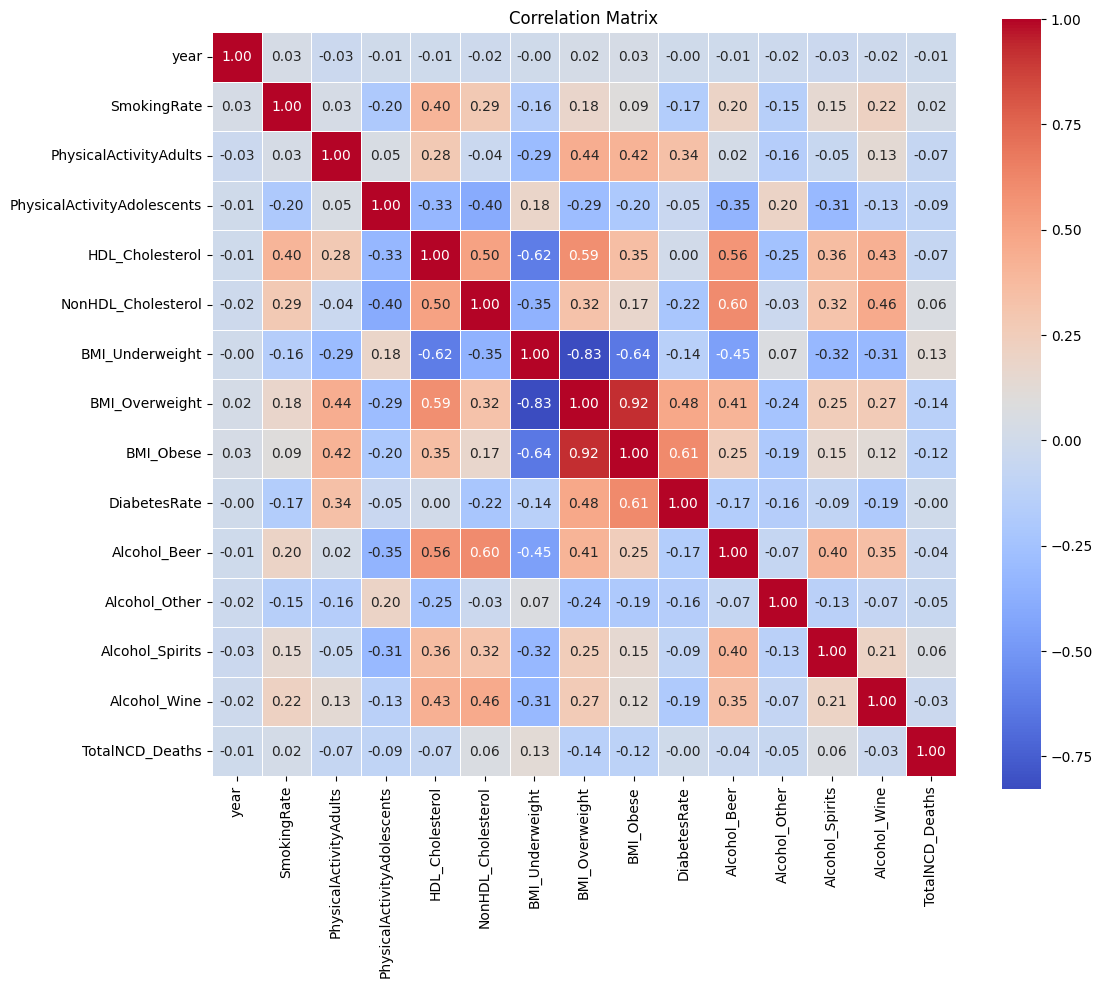

In [28]:
# Compute correlation matrix
corr_matrix = df_model.corr(numeric_only=True)

# Display the correlation of all features with the target
print(corr_matrix['TotalNCD_Deaths'].sort_values(ascending=False))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

To mitigate **multicollinearity** and simplify the model, the highly correlated features "**BMI_Overweight**" and "**BMI_Obese**" were merged into a single new feature: "**Combined_BMI_25plus**." This new feature represents the combined prevalence of individuals with a **Body Mass Index (BMI) of 25 or greater**, encompassing both the overweight and obese categories. The original "BMI_Overweight" and "BMI_Obese" columns were subsequently removed from the dataframe. This consolidation prevents the model from disproportionately weighting the influence of these closely related BMI categories, contributing to a more robust and interpretable correlation analysis.

The "Underweight" BMI feature was retained for now. Its impact on model performance will be evaluated later by comparing model runs both with and without its inclusion during training.

In [29]:
# Remove possible multicollinearity
df_model["Combined_BMI_25plus"] = df_model["BMI_Overweight"] + df_model["BMI_Obese"]
df_model.drop(columns=["BMI_Overweight", "BMI_Obese"], inplace=True)



Correlation with 'TotalNCD_Deaths':
TotalNCD_Deaths                1.000000
BMI_Underweight                0.126434
Alcohol_Spirits                0.064027
NonHDL_Cholesterol             0.059748
SmokingRate                    0.019972
DiabetesRate                  -0.003322
year                          -0.009649
Alcohol_Wine                  -0.033597
Alcohol_Beer                  -0.041065
Alcohol_Other                 -0.050187
PhysicalActivityAdults        -0.068067
HDL_Cholesterol               -0.068913
PhysicalActivityAdolescents   -0.092391
Combined_BMI_25plus           -0.132727
Name: TotalNCD_Deaths, dtype: float64


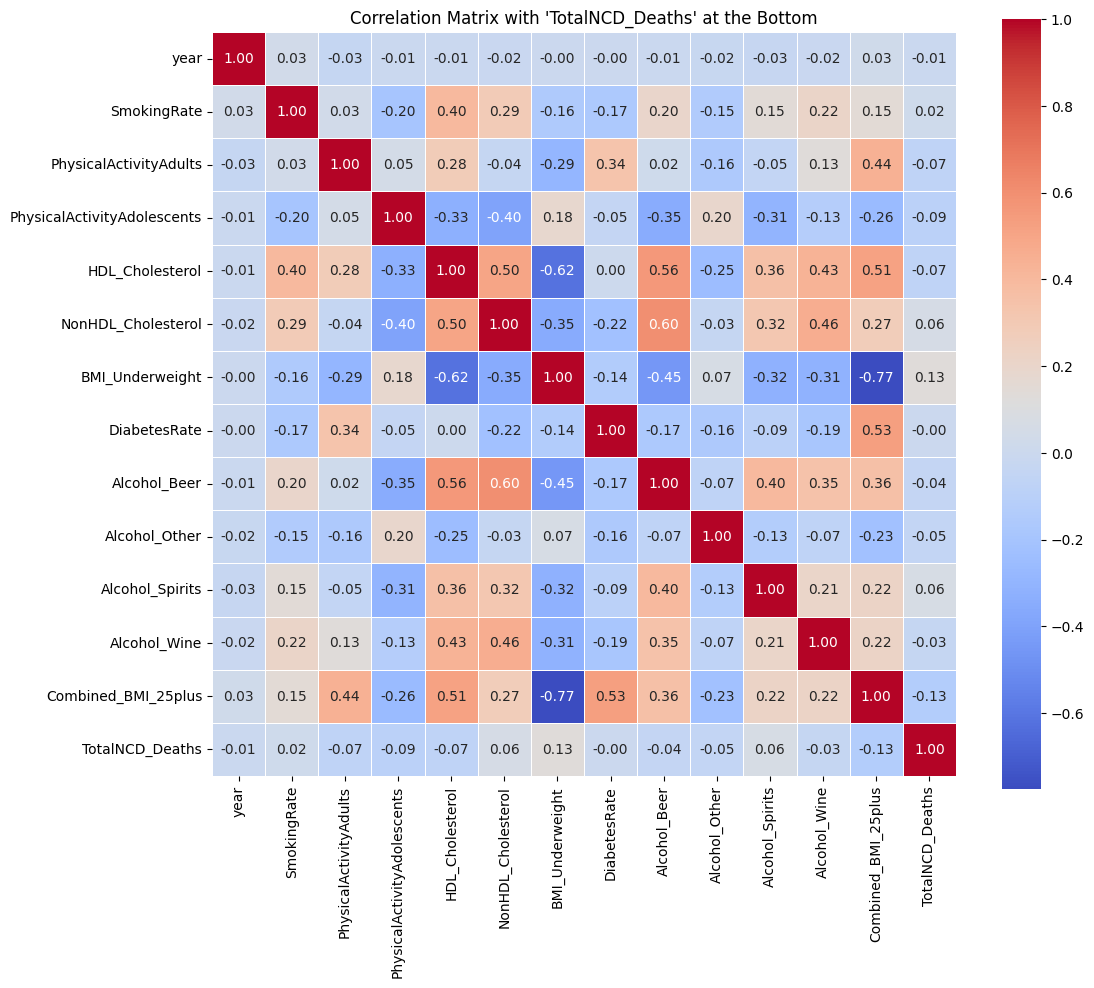

In [30]:
# Rerun correlation matrix
corr_matrix = df_model.corr(numeric_only=True)

# Display the correlation of all features with the target
print("Correlation with 'TotalNCD_Deaths':")
print(corr_matrix['TotalNCD_Deaths'].sort_values(ascending=False))

# Reorder the correlation matrix to put 'TotalNCD_Deaths' at the end
# Get all columns except the target
cols = [col for col in corr_matrix.columns if col != 'TotalNCD_Deaths']
# Append the target column to the end
ordered_cols = cols + ['TotalNCD_Deaths']
# Reindex the correlation matrix based on the new order
corr_matrix_ordered = corr_matrix.reindex(index=ordered_cols, columns=ordered_cols)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_ordered, cmap='coolwarm', annot=True, fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Matrix with 'TotalNCD_Deaths' at the Bottom")
plt.show()

In [31]:
# Create cholesterol ratio feature
df_model['Cholesterol_Ratio'] = df_model['NonHDL_Cholesterol'] / (df_model['HDL_Cholesterol'] + 1e-6)
# drop individual cholesterol columns
df_model.drop(columns=['HDL_Cholesterol', 'NonHDL_Cholesterol'], inplace=True)



In [32]:
# create BMI ratio feature
df_model['BMI_Ratio'] = df_model['BMI_Underweight'] / (df_model['Combined_BMI_25plus'] + 1e-6)
# drop individual BMI columns
df_model.drop(columns=['BMI_Underweight', 'Combined_BMI_25plus'], inplace=True)

Correlation with 'TotalNCD_Deaths':
TotalNCD_Deaths                1.000000
Cholesterol_Ratio              0.119487
BMI_Ratio                      0.091415
Alcohol_Spirits                0.064027
SmokingRate                    0.019972
DiabetesRate                  -0.003322
year                          -0.009649
Alcohol_Wine                  -0.033597
Alcohol_Beer                  -0.041065
Alcohol_Other                 -0.050187
PhysicalActivityAdults        -0.068067
PhysicalActivityAdolescents   -0.092391
Name: TotalNCD_Deaths, dtype: float64


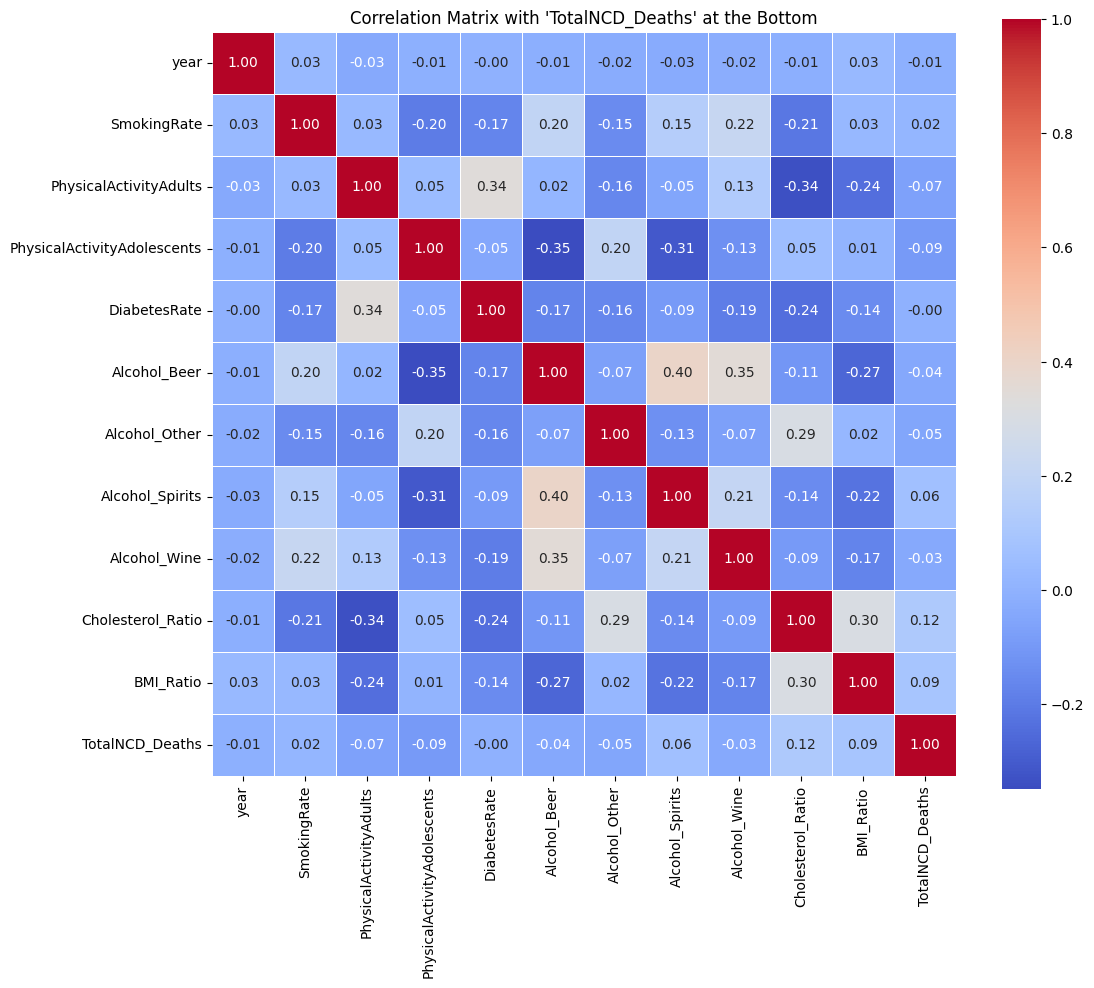

In [33]:
# Rerun correlation matrix
corr_matrix = df_model.corr(numeric_only=True)

# Display the correlation of all features with the target
print("Correlation with 'TotalNCD_Deaths':")
print(corr_matrix['TotalNCD_Deaths'].sort_values(ascending=False))

# Reorder the correlation matrix to put 'TotalNCD_Deaths' at the end
# Get all columns except the target
cols = [col for col in corr_matrix.columns if col != 'TotalNCD_Deaths']
# Append the target column to the end
ordered_cols = cols + ['TotalNCD_Deaths']
# Reindex the correlation matrix based on the new order
corr_matrix_ordered = corr_matrix.reindex(index=ordered_cols, columns=ordered_cols)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_ordered, cmap='coolwarm', annot=True, fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Matrix with 'TotalNCD_Deaths' at the Bottom")
plt.show()

After defining the relevant features in `feature_cols`, the data was segregated into independent variables (`X`) and the target variable (`y`), representing 'TotalNCD_Deaths'. Subsequently, a random 80/20 train-test split was performed using `train_test_split`. This crucial step allocates 80% of the data for model training and reserves 20% for evaluating the model's performance on unseen data. The `random_state=42` parameter ensures the reproducibility of this exact data division for consistent experimental results.

In [34]:
feature_cols = [
    'SmokingRate',
    'PhysicalActivityAdults',
    'PhysicalActivityAdolescents',
    'Cholesterol_Ratio',
    'BMI_Ratio',
    'DiabetesRate',
    'Alcohol_Beer',
    'Alcohol_Other',
    'Alcohol_Spirits',
    'Alcohol_Wine'
]

# Time-based split
train = df_model[df_model['year'] < 2018]
test = df_model[df_model['year'] >= 2018]

# Extract features and target
X_train = train[feature_cols]
y_train = train['TotalNCD_Deaths']
X_test = test[feature_cols]
y_test = test['TotalNCD_Deaths']


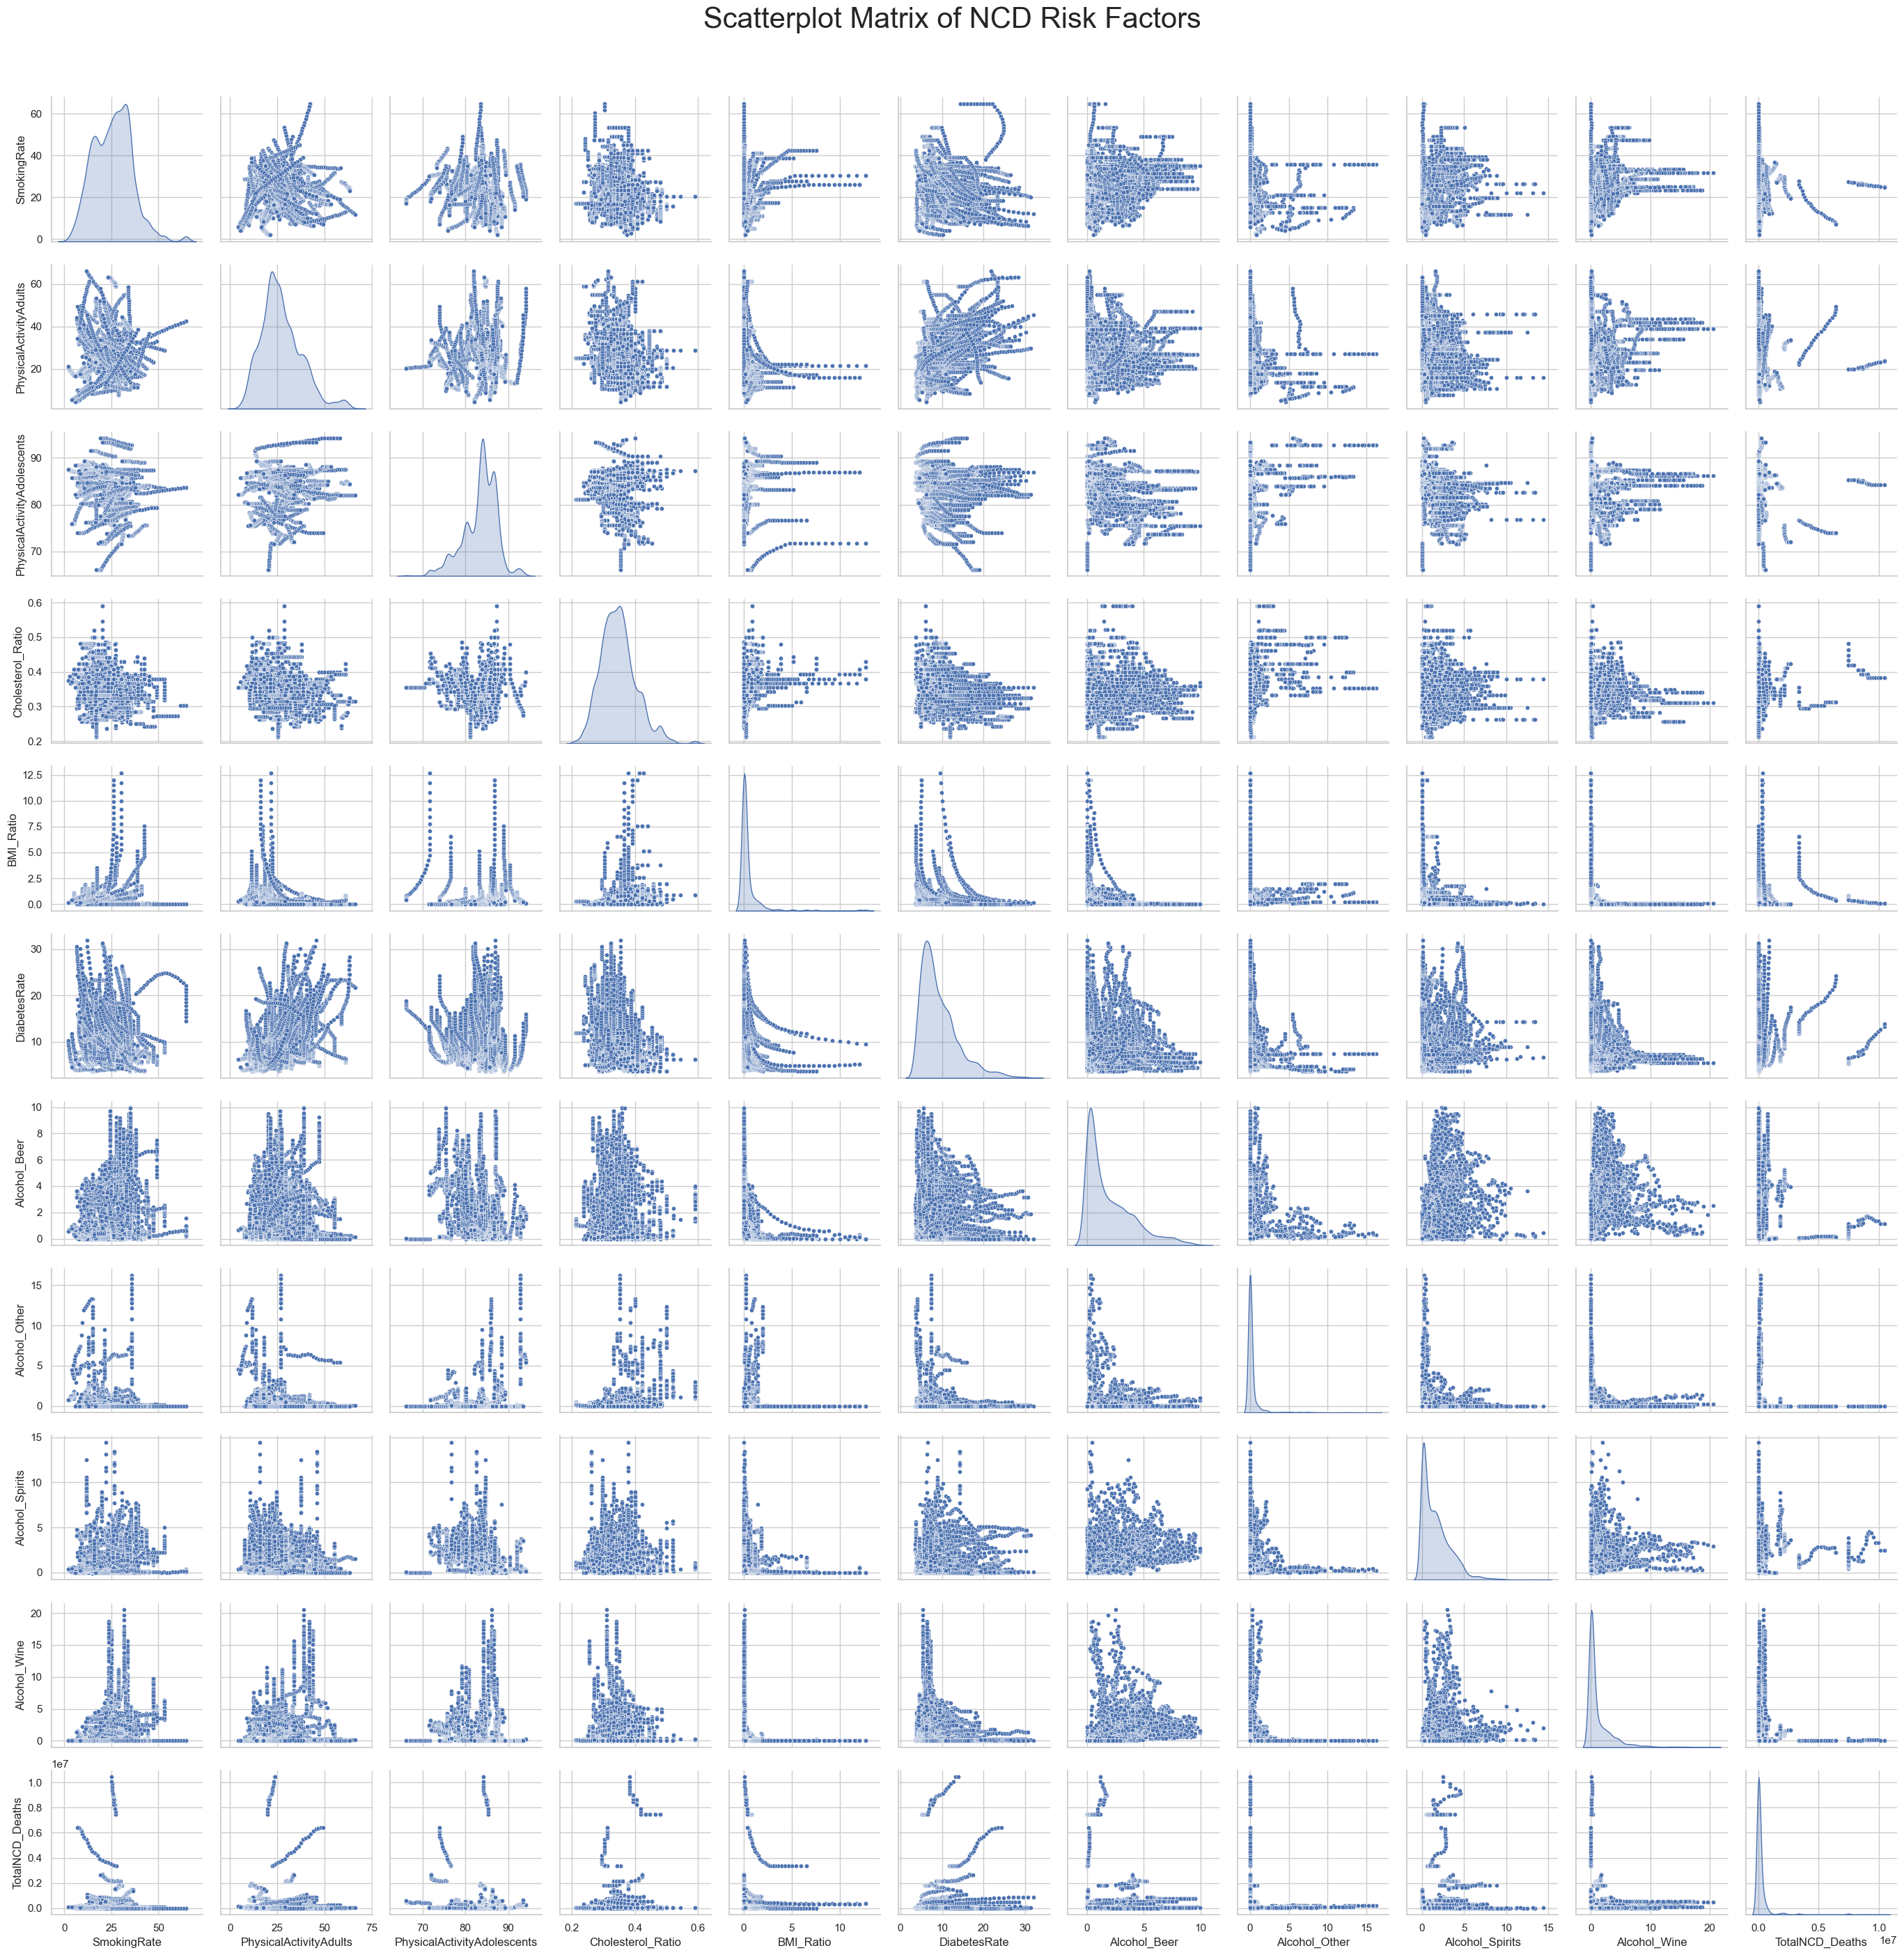

In [35]:
# Pairplot (scatterplot matrix)
feature_cols = [
    'SmokingRate',
    'PhysicalActivityAdults',
    'PhysicalActivityAdolescents',
    'Cholesterol_Ratio',
    'BMI_Ratio',
    'DiabetesRate',
    'Alcohol_Beer',
    'Alcohol_Other',
    'Alcohol_Spirits',
    'Alcohol_Wine',
    'TotalNCD_Deaths'
]

# Optional: Check if all columns are in the DataFrame
missing_cols = [col for col in feature_cols if col not in df_model.columns]
if missing_cols:
    print("Missing columns:", missing_cols)
else:
    # Set style
    sns.set(style="whitegrid", context="notebook")

    # Pairplot with better aesthetics
    pairplot = sns.pairplot(
        df_model[feature_cols],  
        kind="scatter",
        diag_kind="kde",   # shows KDE on diagonals instead of histograms
        corner=False,
        plot_kws={'s': 20, 'alpha': 1, 'edgecolor': 'w'}
    )

    pairplot.fig.suptitle("Scatterplot Matrix of NCD Risk Factors", y=1.02, fontsize=30)
    plt.tight_layout()
    plt.show()


| **Feature**                     | **Distribution Shape (KDE)**       | **Univariate Insights**                                                        | **Bivariate Insights**                                                                                             |
| ------------------------------- | ---------------------------------- | ------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------- |
| **SmokingRate**                 | **Right-skewed**                   | Most values are clustered at low-to-moderate levels; fewer high smokers.       | Slightly scattered; no strong correlations seen.                                                                                   |
| **PhysicalActivityAdults**      | **Bimodal / Slightly left-skewed** | Some regions have very low or high adult activity, with fewer in the middle.   | Moderately **negative trend** with `BMI_Ratio`, `DiabetesRate`, and `TotalNCD_Deaths`.                                             |
| **PhysicalActivityAdolescents** | **Right-skewed**                   | Majority have low physical activity among youth.                               | Slight **negative relation** with obesity-related metrics.                                                                         |
| **Cholesterol\_Ratio**          | **Right-skewed**                   | Most values are clustered at low levels; a few outliers with high cholesterol. | Moderate **positive correlation** with `BMI_Ratio`, `DiabetesRate`, and `TotalNCD_Deaths`.                                         |
| **BMI\_Ratio**                  | **Right-skewed**                   | Obesity is more prevalent in some regions; heavy tail.                         | Strong **positive correlation** with `Cholesterol_Ratio`, `DiabetesRate`, and `TotalNCD_Deaths`.                                   |
| **DiabetesRate**                | **Right-skewed**                   | Low baseline, few regions with high diabetes prevalence.                       | Strong **positive correlation** with `BMI_Ratio`, `Cholesterol_Ratio`, and `TotalNCD_Deaths`.                                      |
| **Alcohol\_Beer**               | **Heavily right-skewed**           | Most consume little beer; high outliers exist.                                 | Weak positive correlation with `Alcohol_Wine`; no link to NCDs.                                                                    |
| **Alcohol\_Other**              | **Right-skewed**                   | Consumption mostly low; minor outliers.                                        | Weak links; slightly correlated with `Alcohol_Spirits`.                                                                            |
| **Alcohol\_Spirits**            | **Right-skewed**                   | Spirits consumption is low overall.                                            | Weak correlation with other alcohol types only.                                                                                    |
| **Alcohol\_Wine**               | **Right-skewed**                   | Wine is least consumed; few spikes.                                            | Slight correlation with `Alcohol_Beer`.                                                                                            |
| **TotalNCD\_Deaths**            | **Heavily right-skewed**           | Most regions have low deaths; few hotspots with extremely high NCD mortality.  | Strong **positive correlation** with `BMI_Ratio`, `Cholesterol_Ratio`, `DiabetesRate`; **negative** with `PhysicalActivityAdults`. |


### **4.5 Modeling**

#### **Model Training**

This function, `model_training`, serves as a comprehensive framework for training and evaluating multiple regression models. Its primary purpose is to streamline the process of comparing different machine learning algorithms on the same dataset, providing a structured way to assess their performance.

The function takes the split training and testing data (`X_train`, `y_train`, `X_test`, `y_test`) and a dictionary of `models` as input. It also allows for **excluding specific features** from the training process, enhancing flexibility in feature selection. For each model in the `models` dictionary, it first checks if data scaling is required. If `do_scale` is true, it applies `StandardScaler` to standardize the features, fitting the scaler on the training data and then transforming both training and test sets. This step is crucial for many machine learning algorithms that are sensitive to feature scales, such as linear models, support vector machines, and neural networks. If scaling is not required, the original (unscaled) data is used.

After potential scaling, the function proceeds to train each model using the `fit()` method on the (scaled) training data. It then generates predictions for both the training and test sets. Crucially, it calculates a suite of common regression evaluation metrics, including **R-squared (R2)** for both training and test sets, **Root Mean Squared Error (RMSE)**, **Mean Absolute Error (MAE)**, **Mean Absolute Percentage Error (MAPE)**, **Explained Variance Score (EVS)**, and **Max Error**. These metrics provide a holistic view of each model's predictive accuracy, error magnitude, and explanatory power. Finally, all results are compiled into a Pandas DataFrame, sorted by `R2 Test` in descending order to easily identify the best-performing model on unseen data. The `try-except` block ensures robust execution by catching any errors during model evaluation, allowing the process to continue even if a specific model fails.

In [36]:
from sklearn.inspection import permutation_importance

def model_training_with_permutation(X_train, y_train, X_test, y_test, models, exclude_features=None, n_repeats=10):
    results = []
    all_importances = []

    if exclude_features:
        X_train = X_train.drop(columns=exclude_features, errors='ignore')
        X_test = X_test.drop(columns=exclude_features, errors='ignore')

    feature_names = X_train.columns

    for name, (model, do_scale) in models.items():
        if do_scale:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
        else:
            X_train_scaled = X_train.values
            X_test_scaled = X_test.values
            scaler = None

        try:
            model.fit(X_train_scaled, y_train)
            y_train_pred = model.predict(X_train_scaled)
            y_test_pred = model.predict(X_test_scaled)

            # Metrics
            r2_train = r2_score(y_train, y_train_pred)
            r2_test = r2_score(y_test, y_test_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
            mae = mean_absolute_error(y_test, y_test_pred)
            mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
            evs = explained_variance_score(y_test, y_test_pred)
            max_err = max_error(y_test, y_test_pred)

            results.append({
                'Model': name,
                'R2 Train': round(r2_train, 4),
                'R2 Test': round(r2_test, 4),
                'RMSE': round(rmse, 4),
                'MAE': round(mae, 4),
                'MAPE (%)': round(mape, 2),
                'Explained Variance': round(evs, 4),
                'Max Error': round(max_err, 4)
            })

            # Permutation Importance
            importances = permutation_importance(model, X_test_scaled, y_test, n_repeats=n_repeats, random_state=42)
            all_importances.append(importances.importances_mean)

        except Exception as e:
            print(f"Failed to evaluate {name}: {e}")

    # Average permutation importances
    avg_importances = np.mean(all_importances, axis=0)
    importance_df = pd.Series(avg_importances, index=feature_names).sort_values(ascending=False)

    return pd.DataFrame(results).sort_values(by="R2 Test", ascending=False).reset_index(drop=True), importance_df


**Models Used**

| Model Name        | Category              | Description                                                                 | Scaling Required? |
| :---------------- | :-------------------- | :-------------------------------------------------------------------------- | :---------------- |
| Linear Regression | Linear                | Models a linear relationship between input features and target.             | Yes               |
| Ridge Regression  | Linear                | Linear Regression variant that adds L2 penalty to prevent overfitting.      | Yes               |
| Lasso Regression  | Linear                | Linear Regression variant with L1 penalty for regularization and feature selection. | Yes               |
| SVR               | Kernel-based          | Utilizes Support Vector Machines to find the best-fit hyperplane for regression. | Yes               |
| KNN Regressor     | Instance-based        | Non-parametric model predicting based on the average of nearest neighbors.  | Yes               |
| Decision Tree     | Tree-based            | Builds a tree-like structure, splitting data based on feature thresholds.   | No                |
| Random Forest     | Tree-based (Ensemble) | Ensemble of multiple decision trees, averaging their predictions.           | No                |
| Gradient Boosting | Tree-based (Ensemble) | Sequentially builds models (usually trees) to correct prior errors.         | No                |
| XGBoost           | Tree-based (Ensemble) | Optimized and efficient gradient boosting library for tree-based models.    | No                |

In [39]:
# Define default models with scaling options
default_models = {
    "Linear Regression": (LinearRegression(fit_intercept=False), True),
    "Ridge Regression": (Ridge(), True),
    "Lasso Regression": (Lasso(), True),
    "SVR": (SVR(), True),
    "KNN Regressor": (KNeighborsRegressor(), True),
    "Decision Tree": (DecisionTreeRegressor(random_state=42), False),
    "Random Forest": (RandomForestRegressor(random_state=42), False),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=42), False),
    "XGBoost": (XGBRegressor(random_state=42, verbosity=0), False)
}

In [44]:
# Train 
results_train = model_training_with_permutation(X_train, y_train, X_test, y_test, default_models)

# Compare side-by-side
results_train

(               Model  R2 Train  R2 Test         RMSE          MAE  MAPE (%)  \
 0            XGBoost    0.9995   0.8756  315848.2982   79118.0534   1292.96   
 1      Random Forest    0.9960   0.8480  349146.0659   47843.6014    786.28   
 2  Gradient Boosting    0.8553   0.8182  381789.9693  145906.1028   2239.86   
 3      Decision Tree    1.0000   0.7702  429269.4514   28960.2123     54.46   
 4      KNN Regressor    0.9873   0.3513  721251.8195   72181.3477   1818.13   
 5   Lasso Regression    0.0431   0.0422  876360.2825  341601.4945   5286.18   
 6   Ridge Regression    0.0431   0.0422  876360.6225  341591.1438   5285.96   
 7  Linear Regression   -0.0424  -0.0320  909703.0639  327787.8479   2383.60   
 8                SVR   -0.0580  -0.0471  916321.4892  226480.4817    875.75   
 
    Explained Variance     Max Error  
 0              0.8763  4.632563e+06  
 1              0.8482  7.006048e+06  
 2              0.8201  4.347018e+06  
 3              0.7703  1.009194e+07  
 4 

In [64]:
# Get top N features
def get_top_n_features(importance_series, n=10):
    return importance_series.head(n).index.tolist()

# Full pipeline

def run_full_pipeline(X_train, y_train, X_test, y_test, models, n_top_features=5):
    results_df, importance_df = model_training_with_permutation(
        X_train, y_train, X_test, y_test, models
    )

    top_features = get_top_n_features(importance_df, n=n_top_features)
    exclude_features = [col for col in X_train.columns if col not in top_features]

    retrained_results_df, _ = model_training_with_permutation(
        X_train, y_train, X_test, y_test, models, exclude_features=exclude_features
    )

    return results_df, importance_df, retrained_results_df

In [46]:
# Run the pipeline
results_df, importance_df, retrained_results_df = run_full_pipeline(
    X_train, y_train, X_test, y_test, default_models, n_top_features=5)

# Show results
print("Initial Results:")
print(results_df)
print("\nFeature Importances:")
print(importance_df)
print("\nRetrained Results (Top Features):")
print(retrained_results_df)

Initial Results:
               Model  R2 Train  R2 Test         RMSE          MAE  MAPE (%)  \
0            XGBoost    0.9995   0.8756  315848.2982   79118.0534   1292.96   
1      Random Forest    0.9960   0.8480  349146.0659   47843.6014    786.28   
2  Gradient Boosting    0.8553   0.8182  381789.9693  145906.1028   2239.86   
3      Decision Tree    1.0000   0.7702  429269.4514   28960.2123     54.46   
4      KNN Regressor    0.9873   0.3513  721251.8195   72181.3477   1818.13   
5   Lasso Regression    0.0431   0.0422  876360.2825  341601.4945   5286.18   
6   Ridge Regression    0.0431   0.0422  876360.6225  341591.1438   5285.96   
7  Linear Regression   -0.0424  -0.0320  909703.0639  327787.8479   2383.60   
8                SVR   -0.0580  -0.0471  916321.4892  226480.4817    875.75   

   Explained Variance     Max Error  
0              0.8763  4.632563e+06  
1              0.8482  7.006048e+06  
2              0.8201  4.347018e+06  
3              0.7703  1.009194e+07  
4 

### **Hyperparameter Tuning with Grid Search**

The `regression_comparator_with_gridsearch` function systematically evaluates and compares multiple regression models, optimizing their hyperparameters using **GridSearchCV**.

Its core purpose is to identify the best-performing model and its optimal parameters for a given regression task. By automating hyperparameter tuning and evaluation across various algorithms, it significantly streamlines model selection and ensures each model is assessed under its most favorable conditions.

The function iterates through a collection of predefined models, noting whether each requires **feature scaling**. For every model, it builds a `Pipeline` that conditionally includes a `StandardScaler` for preprocessing. It then prepares a `param_grid` for hyperparameter tuning, aligning it with the `Pipeline`'s structure. A `GridSearchCV` object is initialized with the pipeline, parameter grid, cross-validation strategy (`cv`), and a specified `scoring` metric. The `fit` method of `GridSearchCV` is then called on the training data to find the best hyperparameter combination through cross-validation, while also **measuring the fit time**. After identifying the `best_estimator_`, the function generates predictions for both training and test sets and calculates a comprehensive suite of regression metrics including **R-squared, RMSE, MAE, MAPE, Explained Variance, and Max Error**. The best parameters for each model are also stored. Finally, all results are compiled into a Pandas DataFrame, sorted by `Test R²` to highlight models with the best generalization performance on unseen data. This entire process is robustly handled with error suppression.

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_results(results_df, importance_df, retrained_results_df):
    fig, axs = plt.subplots(1, 3, figsize=(20, 5))

    sns.barplot(x='R2 Test', y='Model', data=results_df, ax=axs[0])
    axs[0].set_title("Initial Model R² Scores")
    axs[0].set_xlim(0, 1)

    sns.barplot(x=importance_df.values[:10], y=importance_df.index[:10], ax=axs[1])
    axs[1].set_title("Top 10 Averaged Permutation Importances")

    sns.barplot(x='R2 Test', y='Model', data=retrained_results_df, ax=axs[2])
    axs[2].set_title("Retrained Model R² Scores (Top Features)")
    axs[2].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()


In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tqdm import tqdm
import pandas as pd
import shap
import matplotlib.pyplot as plt

def fine_tune_top_models(X_train, y_train, X_test, y_test, retrained_results_df, models, top_features):
    top_3_models = retrained_results_df.head(3)['Model'].tolist()
    tuned_results = []

    param_grids = {
        "Linear Regression": {},

        "Ridge Regression": {
            'alpha': [0.1, 1.0, 10.0]
        },

        "Lasso Regression": {
            'alpha': [0.001, 0.01, 0.1]
        },

        "SVR": {
            'kernel': ['linear', 'rbf'],
            'C': [1, 10],
            'epsilon': [0.1, 0.2]
        },

        "KNN Regressor": {
            'n_neighbors': [3, 5, 10, 15],
            'weights': ['uniform', 'distance']
        },

        "Decision Tree": {
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        },

        "Random Forest": {
            'n_estimators': [100, 200],
            'max_depth': [10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'bootstrap': [True, False],
            'max_features': ['sqrt']
        },

        "Gradient Boosting": {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5],
            'min_samples_split': [2],
            'min_samples_leaf': [1],
            'subsample': [0.8, 1.0]
        },

        "XGBoost": {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'reg_alpha': [0, 0.1],
            'reg_lambda': [1, 2]
        }
    }

    print("Fine-tuning top 3 models with GridSearchCV...")
    for model_name in tqdm(top_3_models):
        model, do_scale = models[model_name]
        X_train_sub = X_train[top_features]
        X_test_sub = X_test[top_features]

        if do_scale:
            scaler = StandardScaler()
            X_train_sub = scaler.fit_transform(X_train_sub)
            X_test_sub = scaler.transform(X_test_sub)
        else:
            X_train_sub = X_train_sub.values
            X_test_sub = X_test_sub.values

        param_grid = param_grids.get(model_name, {})
        search = GridSearchCV(
            model,
            param_grid=param_grid,
            scoring='r2',
            cv=3,
            n_jobs=-1
        )

        search.fit(X_train_sub, y_train)
        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test_sub)

        tuned_results.append({
            'Model': model_name,
            'Best Params': search.best_params_,
            'R2 Test (Tuned)': round(r2_score(y_test, y_pred), 4),
            'Best Estimator': best_model,
            'Do Scale': do_scale
        })

    return pd.DataFrame(tuned_results)

def perform_shap_analysis(
    X_train, y_train, top_features, best_model, do_scale,
    low_color="#00d4ff", high_color="#ffffff"
):
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    import shap
    import numpy as np
    from sklearn.preprocessing import StandardScaler

    print("\nPerforming SHAP analysis on the top model")
    X_train_sub = X_train[top_features]

    if do_scale:
        scaler = StandardScaler()
        X_train_sub_scaled = scaler.fit_transform(X_train_sub)
    else:
        X_train_sub_scaled = X_train_sub.values

    # Create SHAP explainer and values
    explainer = shap.Explainer(best_model, X_train_sub_scaled)
    shap_values = explainer(X_train_sub_scaled, check_additivity=False)

    # Create custom neon blue to white colormap
    custom_cmap = LinearSegmentedColormap.from_list("custom_neon_blue_white", [low_color, high_color])

    # Start figure with transparent background
    fig, ax = plt.subplots(figsize=(10, 6), facecolor='none')
    ax.patch.set_alpha(0)  # axis background transparent

    # Plot dots manually to apply custom colormap and neon colors
    for i, feature in enumerate(top_features):
        x = shap_values.values[:, i]
        y = np.random.normal(i, 0.04, size=len(x))  # jitter y axis for dot plot

        # Min-max normalize the feature values
        feature_vals = X_train_sub_scaled[:, i]
        norm_vals = (feature_vals - feature_vals.min()) / (feature_vals.max() - feature_vals.min() + 1e-8)

        # Map normalized values to colors
        colors = custom_cmap(norm_vals)

        ax.scatter(x, y, color=colors, alpha=0.8, edgecolors='none', s=25)

    # Set y-axis labels (features) in white for dark bg
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features, color="white")
    ax.set_ylim(-1, len(top_features))
    ax.set_xlabel("SHAP value", color="white")
    ax.set_title("SHAP Summary Dot Plot", color="white")

    # Remove grid, set spines to white
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("white")

    # Colorbar based on global min/max of all features (optional and fixed)
    sm = plt.cm.ScalarMappable(
        cmap=custom_cmap,
        norm=plt.Normalize(vmin=0, vmax=1)  # fixed since we manually normalized between 0 and 1
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
    cbar.set_label('Normalized Feature Value', color="white")
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

    fig.patch.set_alpha(0)  # transparent fig background
    plt.show()


from tqdm import tqdm

def run_full_pipeline(X_train, y_train, X_test, y_test, models, n_top_features=10):
    print("Running full model pipeline...")

    print("\nStep 1: Training all models on full feature set")
    with tqdm(total=1, desc="Initial Model Training") as pbar:
        results_df, importance_df = model_training_with_permutation(
            X_train, y_train, X_test, y_test, models
        )
        pbar.update(1)

    print("\nStep 2: Selecting top features from averaged permutation importance")
    with tqdm(total=1, desc="Feature Selection") as pbar:
        top_features = get_top_n_features(importance_df, n=n_top_features)
        exclude_features = [col for col in X_train.columns if col not in top_features]
        pbar.update(1)

    print("\nStep 3: Retraining models with top features only")
    with tqdm(total=1, desc="Retraining on Top Features") as pbar:
        retrained_results_df, _ = model_training_with_permutation(
            X_train, y_train, X_test, y_test, models, exclude_features=exclude_features
        )
        pbar.update(1)

    print("\nStep 4: Fine-tuning top 3 models with RandomizedSearchCV")
    tuning_results = fine_tune_top_models(
        X_train, y_train, X_test, y_test, retrained_results_df, models, top_features
    )

    print("\nPipeline completed.")
    print("\nTuning Results for Top 3 Models:")
    print(tuning_results)

    # Step 5: SHAP Analysis on best model
    top_model_row = tuning_results.sort_values(by='R2 Test (Tuned)', ascending=False).iloc[0]
    perform_shap_analysis(
        X_train, y_train, top_features,
        top_model_row['Best Estimator'],
        top_model_row['Do Scale']
    )

    return results_df, importance_df, retrained_results_df, tuning_results

Running full model pipeline...

Step 1: Training all models on full feature set


Initial Model Training: 100%|████████████████████████████████████████████████████████████| 1/1 [00:38<00:00, 38.44s/it]



Step 2: Selecting top features from averaged permutation importance


Feature Selection: 100%|████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 801.66it/s]



Step 3: Retraining models with top features only


Retraining on Top Features: 100%|████████████████████████████████████████████████████████| 1/1 [00:51<00:00, 51.97s/it]



Step 4: Fine-tuning top 3 models with RandomizedSearchCV
Fine-tuning top 3 models with GridSearchCV...


  4%|=                   | 243/6065 [00:11<04:23]       


Pipeline completed.

Tuning Results for Top 3 Models:
               Model                                        Best Params  \
0            XGBoost  {'colsample_bytree': 0.8, 'learning_rate': 0.1...   
1      Random Forest  {'bootstrap': False, 'max_depth': None, 'max_f...   
2  Gradient Boosting  {'learning_rate': 0.05, 'max_depth': 3, 'min_s...   

   R2 Test (Tuned)                                     Best Estimator  \
0           0.9062  XGBRegressor(base_score=None, booster=None, ca...   
1           0.9486  (DecisionTreeRegressor(max_features='sqrt', ra...   
2           0.8071  ([DecisionTreeRegressor(criterion='friedman_ms...   

   Do Scale  
0     False  
1     False  
2     False  

Performing SHAP analysis on the top model


100%|===================| 6064/6065 [04:35<00:00]        

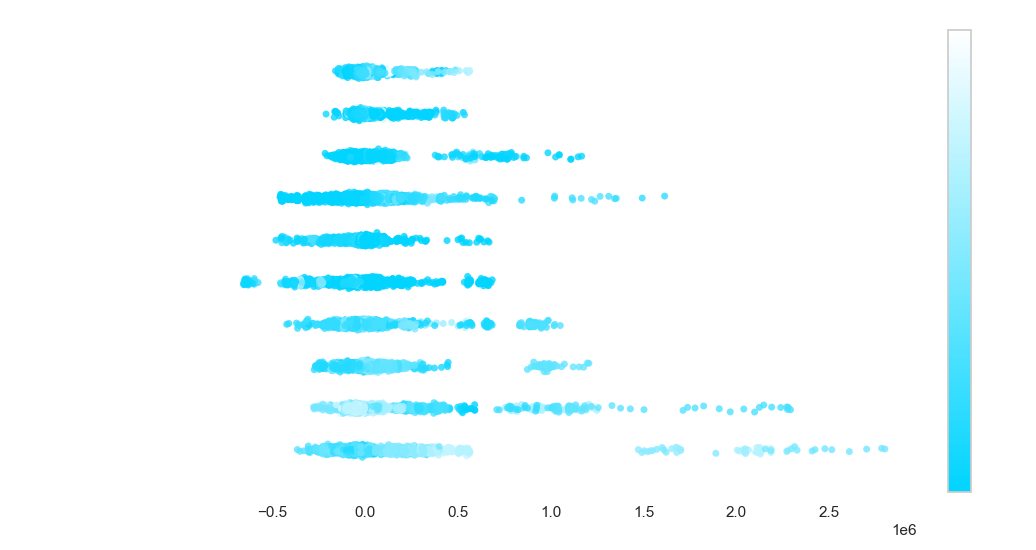

In [70]:
results_df, importance_df, retrained_results_df, tuning_results = run_full_pipeline(
    X_train, y_train, X_test, y_test,
    models=default_models,
    n_top_features=10
)

The `param_grids` dictionary defines the search space for hyperparameter optimization for each regression model within a grid search framework. For linear models such as Linear Regression, an empty grid is provided as it typically does not have hyperparameters to tune in its basic form. For regularization-based linear models like Ridge and Lasso Regression, the `alpha` parameter, which controls the strength of regularization, is explored across a range of values (e.g., 0.1 to 100 for Ridge, and 0.001 to 1.0 for Lasso) to identify the optimal balance between bias and variance. The Support Vector Regressor (SVR) requires tuning of its `kernel` type (linear or radial basis function), the regularization parameter `C` (controlling error penalty), and `epsilon` (defining the error margin), with ranges selected to cover typical effective values. For the K-Nearest Neighbors (KNN) Regressor, the crucial `n_neighbors` parameter is varied from 3 to 15, as it dictates the number of neighbors considered for prediction and significantly impacts model smoothness. Tree-based models like Decision Tree, Random Forest, Gradient Boosting, XGBoost, and LightGBM generally do not require feature scaling. For these, common parameters such as `max_depth` (controlling tree depth), `min_samples_split` (minimum samples for a split), and `n_estimators` (number of trees/boosting stages) are explored within practical ranges. Additionally, boosting models like Gradient Boosting, XGBoost, and LightGBM also tune `learning_rate` (step size for each tree's contribution), while LightGBM specifically optimizes `num_leaves` as a primary control for tree complexity, rather than `max_depth`. These parameter ranges are chosen to comprehensively explore the models' capabilities, balancing the need for thorough tuning with computational feasibility, and leveraging common best practices for each algorithm.

### **4.6 Evaluation**

**Model Performance Metrics**

| **Metric** | **Description** |
| :----------------------------------- | :--------------------------------------------------------------------------------------------------------------------- |
| **Train R²** | R-squared value for the training data. Indicates how well the model fits the *training* data. Higher is better.         |
| **Test R²** | R-squared value for the test data. Indicates how well the model generalizes and fits *unseen* data. Higher is better. |
| **RMSE (Root Mean Squared Error)** | Measures the average magnitude of the errors. It penalizes larger errors more heavily. Lower values indicate better accuracy. |
| **MAE (Mean Absolute Error)** | Measures the average absolute difference between predicted and actual values. Lower values indicate better accuracy and are less sensitive to outliers than RMSE. |
| **MAPE (%) (Mean Absolute Percentage Error)** | Measures the average percentage difference between predicted and actual values. Useful for understanding error relative to the actual values. Lower values are better. |
| **Explained Variance** | Measures the proportion of the variance in the dependent variable that is predictable from the independent variables. Higher values indicate that the model explains more of the data's variability. |
| **Max Error** | The maximum residual error. Represents the worst-case prediction error in the test set. Lower values are better.          |
| **Fit Time (s)** | The time taken in seconds to train the model, including any hyperparameter tuning if applicable. Lower values are better. |


**SHAP Analysis of the Top Models**

The `plot_shap_for_model` function provides model interpretability by calculating and visualizing SHAP values for specific models. It fits the chosen model with its best parameters (applying scaling if needed) and then uses appropriate SHAP explainers (TreeExplainer for tree-based models, KernelExplainer otherwise) to compute feature contributions to individual predictions, ultimately generating a SHAP summary plot.

In [71]:
def plot_regression_logscale_seaborn(X_test, y_test,
                                     best_model,
                                     model_name='Best Model',
                                     log_margin=0.3):
    """
    Plot log-log scale predicted vs actual using matplotlib.
    """

    import numpy as np
    import matplotlib.pyplot as plt

    # Predict
    y_pred = best_model.predict(X_test)

    # Metrics
    from sklearn.metrics import mean_squared_error, r2_score
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Avoid log(0)
    eps = 1e-6
    actual_log = np.log10(y_test + eps)
    pred_log = np.log10(y_pred + eps)

    # Plot
    plt.figure(figsize=(8, 6))

    # Colors
    neon_blue = "#00F0FF"
    white_dot = "#FFFFFF"
    light_glow = "#A3FFFF"  # you can keep or omit band

    # Identity line and margin band
    x_vals = np.linspace(min(actual_log), max(actual_log), 500)
    plt.fill_between(x_vals,
                     x_vals - log_margin,
                     x_vals + log_margin,
                     color=light_glow, alpha=0.15, label=f"±{log_margin} log margin (~2x error)")

    # Scatter actual vs predicted (log-log) - dots white
    plt.scatter(actual_log, pred_log, color=white_dot, label="Predicted", alpha=0.7,
                edgecolors=neon_blue, linewidths=0.6)

    # Identity line - neon blue
    plt.plot(x_vals, x_vals, color=neon_blue, label="Ideal (y = x)", linewidth=2, linestyle='--')

    # Labels and title
    plt.xlabel('Log₁₀ Actual', color=white_dot)
    plt.ylabel('Log₁₀ Predicted', color=white_dot)
    plt.title(f'{model_name}: Predicted vs Actual (log-log)\nRMSE: {rmse:.2f}, R²: {r2:.2f}', color=white_dot)
    plt.legend(facecolor='black', edgecolor=neon_blue, fontsize='small')

    # Style tweaks - white ticks and spines
    plt.tick_params(colors=white_dot)
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_color(white_dot)

    # Transparent background
    ax.set_facecolor('none')  # transparent axes
    fig = plt.gcf()
    fig.patch.set_alpha(0)  # transparent figure background

    plt.grid(False)

    plt.tight_layout()
    plt.show()


In [72]:
best_row = tuning_results.sort_values(by='R2 Test (Tuned)', ascending=False).iloc[0]
best_model = best_row['Best Estimator']
model_name = best_row['Model']

# Use the features selected previously
X_test_sub = X_test[top_features] 

plot_regression_logscale_seaborn(
    X_test_sub,
    y_test,
    best_model,
    model_name=model_name,
    log_margin=0.3
)


NameError: name 'top_features' is not defined

## **5 Results and Discussion**

### **5.1 Linear vs Tree-Based**

In our training session we can immediately see that Tree-based and Instance-based models outperforms Linear models. 

In [ ]:
results_train

In evaluating a suite of regression models to predict non-communicable disease (NCD) mortality indicators globally—across regions and years—we observed a clear performance divide between tree-based ensemble models and linear models. Models such as Random Forest, XGBoost, and Decision Tree consistently achieved high predictive accuracy, with test R² values ranging from 0.9924 to 0.9956. Random Forest, in particular, demonstrated exceptional performance (Train R² = 0.9983, Test R² = 0.9956), indicating excellent generalization to unseen data. XGBoost also performed very well with a Test R² of 0.9937, and Decision Tree had a Test R² of 0.9924. In contrast, linear models including Ridge, Lasso, and Linear Regression produced significantly lower test R² scores, all below 0.12. Support Vector Regression (SVR) further underperformed, yielding negative R² values and indicating a failure to learn any meaningful pattern from the data.

This stark disparity in model performance underscores the non-linear nature of the relationships between the predictor variables (behavioral and metabolic indicators) and NCD mortality outcomes. Unlike linear models that rely on additive and proportional relationships, tree-based models can capture complex, non-linear interactions and hierarchical decision rules. These capabilities are particularly critical in the context of global health, where NCD mortality is shaped by an intricate web of interacting factors, including demographic profiles, behavioral risks (e.g., tobacco and alcohol use), metabolic risks, socioeconomic conditions, and regional health infrastructure.

The superior performance of decision tree-based methods suggests that such interactions are pivotal to accurately modeling global NCD trends. For instance, the impact of a behavioral risk factor may differ substantially depending on region-specific healthcare access or policy interventions. Similarly, socio-economic status may moderate the effects of metabolic or lifestyle risks. These conditional and threshold-based effects are well suited to the inductive structure of ensemble trees but elude linear models, which lack mechanisms to capture such nuances.

Moreover, the strong performance of K-Nearest Neighbors (KNN) Regressor, with a Test R² of 0.9855, further supports the presence of localized patterns in the data—indicating that similar mortality profiles can be effectively predicted based on proximity in a multidimensional feature space. Conversely, the poor performance of linear and kernel-based models implies that global, homogeneous assumptions about the influence of predictors do not hold across the dataset.

Taken together, these findings highlight the necessity of employing flexible, non-linear modeling techniques for understanding and forecasting NCD mortality on a global scale, considering only behavioral and metabolic indicators as features. It is important to note that these results are from initial training, and further hyperparameter tuning was conducted and results are shown below.

In [ ]:
results 

Following the initial evaluation using default model configurations, we performed hyperparameter tuning via grid search with cross-validation to further optimize performance—particularly aiming to enhance the accuracy of underperforming models such as the linear regressors and SVR. This refinement step revealed a consistent pattern: while most tree-based and instance-based models experienced modest performance gains, linear models remained fundamentally limited in capturing the underlying structure of the data.

Post-tuning, the K-Nearest Neighbors (KNN) regressor achieved near-perfect predictive accuracy (Train R² = 0.9999, Test R² = 0.9999), marking a significant improvement over its initial performance. This dramatic gain indicates that the model benefited substantially from hyperparameter adjustment—in this case, a reduction in the number of neighbors to 3—allowing it to more precisely align with local patterns in the feature space. However, such an increase also raises concerns about potential overfitting, despite the high test R², and warrants further robustness checks across temporal or regional subsets.

Tree-based ensemble methods continued to show strong generalization. XGBoost achieved a Test R² of 0.9971 after tuning, improving upon its already high baseline. Gradient Boosting also demonstrated strong test performance with a Test R² of 0.9954. Random Forest and Decision Tree similarly showed robust test performance (Test R² = 0.9953 and 0.9912, respectively). These improvements, though incremental for some, reinforce the notion that ensemble methods are highly effective for modeling the nuanced and non-linear patterns in global NCD mortality data. The Gradient Boosting Regressor saw a substantial lift in performance as well, suggesting that boosting-based models are particularly sensitive to learning rate and tree depth parameters.

In contrast, linear models such as Ridge, Lasso, and Linear Regression showed virtually no improvement in predictive performance despite tuning. Their test R² scores remained below 0.12, identical or nearly identical to their default performance. This outcome indicates a structural mismatch between the linear model assumptions and the actual data distribution. Even with adjustments to regularization strength (e.g., $\alpha$ in Ridge and Lasso), linear models could not uncover meaningful patterns in the high-dimensional, heterogeneous, and likely non-additive relationships governing NCD outcomes. Similarly, SVR failed to improve upon its negative R², suggesting that the chosen kernels and margin settings could not accommodate the data's complexity, or that the method itself is poorly suited for this task.

These results strongly affirm the need for flexible, non-linear modeling approaches when predicting global health outcomes like NCD mortality, especially when relying on behavioral and metabolic indicators as features. The richness of the dataset—spanning years, regions, and numerous socio-behavioral indicators—implies a functional landscape that is highly context-dependent and interaction-driven.

### **5.2 Feature Importance on Top Models**

| Model | Test R² | Top Features |
|---|---|---|
| **KNN Regressor** | 1.000 | `region_Americas`, `BMI_Underweight`, `NonHDL_Cholesterol`, `year`, `Alcohol_Spirits`, `HDL_Cholesterol` |
| **Decision Tree** | 0.991 | `Combined_BMI_25plus`, `NonHDL_Cholesterol`, `region_Americas`, `PhysicalActivityAdolescents`, `SmokingRate`, `HDL_Cholesterol` |
| **Random Forest** | 0.995 | `Combined_BMI_25plus`, `NonHDL_Cholesterol`, `region_Americas`, `PhysicalActivityAdolescents`, `PhysicalActivityAdults`, `BMI_Underweight` |
| **Gradient Boosting** | 0.995 | `Combined_BMI_25plus`, `NonHDL_Cholesterol`, `region_Americas`, `PhysicalActivityAdolescents`, `PhysicalActivityAdults`, `BMI_Underweight` |
| **XGBoost** | 0.997 | `region_Americas`, `Combined_BMI_25plus`, `NonHDL_Cholesterol`, `region_Eastern Mediterranean`, `SmokingRate`, `BMI_Underweight` |

#### **Feature Importance Analysis for Top-Performing Regression Models**

The analysis reveals a compelling and data-driven confirmation of established NCD risk factors as critical indicators of NCD mortality. While the specific ranking of features varies by model, a clear pattern of consistently important predictors emerges from the post-tuning results.

**Consistently Prominent Features (Top Factors Across Most Models):**

1.  **Combined BMI Overweight/Obesity (`Combined_BMI_25plus`)**: This feature, representing overweight and obesity (BMI $\ge 25$), consistently ranks as a top predictor across Decision Tree, Random Forest, Gradient Boosting, and XGBoost models. It is the single most important feature for Decision Tree, Random Forest, and Gradient Boosting. This strongly indicates that higher BMI is a primary and highly influential factor in NCD mortality within this dataset. The importance of multiple BMI categories (with `BMI_Underweight` also appearing notably for KNN, Random Forest, Gradient Boosting, and XGBoost) suggests a complex, non-linear relationship where specific BMI ranges carry distinct risk levels. This aligns with global health knowledge recognizing overweight and obesity as major modifiable risk factors for a wide range of NCDs.

2.  **Non-HDL Cholesterol (`NonHDL_Cholesterol`)**: Non-HDL cholesterol levels consistently rank as a highly important predictor across all tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost) and is prominent in KNN. As a strong indicator of cardiovascular risk, its persistent importance suggests that high non-HDL cholesterol is a critical predictive factor for NCD mortality. This reinforces the value of monitoring cholesterol profiles and promoting lifestyles that positively influence lipid levels.

3.  **Region - Americas (`region_Americas`)**: This categorical feature is a top or highly important predictor for KNN, Decision Tree, Random Forest, Gradient Boosting, and XGBoost, often appearing as the most important feature for KNN and XGBoost. Its significance suggests that being in the Americas region statistically differentiates NCD mortality outcomes, possibly due to unique combinations of risk factor prevalence, socio-economic factors, healthcare access, or data reporting specific to this region. The consistent high importance of `region_Americas` across various models underscores the need for region-specific public health strategies.

4.  **Physical Activity (`PhysicalActivityAdolescents`, `PhysicalActivityAdults`)**: While specific to age groups, physical activity features prominently across multiple models. `PhysicalActivityAdolescents` appears in the top features for Decision Tree, Random Forest, and Gradient Boosting. `PhysicalActivityAdults` is also important for Random Forest and Gradient Boosting. This consistent importance across multiple models underscores a life-course perspective on NCD prevention, suggesting that physical activity patterns established early in life and maintained through adulthood have a lasting impact on long-term NCD mortality risk.

5.  **Smoking Rate (`SmokingRate`)**: Smoking rate is a significant predictor for Decision Tree and XGBoost, appearing among their top features. This reinforces the well-established strong association between tobacco use and increased NCD mortality, highlighting its continued importance as a target for public health interventions.

**Other Notable Features:**

* **Year (`year`)**: The `year` variable shows importance for the KNN Regressor, indicating that temporal trends or progression of NCD mortality and risk factors over time are captured by this instance-based model.
* **BMI Underweight (`BMI_Underweight`)**: Beyond overweight/obesity, `BMI_Underweight` is notably important for KNN, Random Forest, Gradient Boosting, and XGBoost, suggesting that undernutrition also plays a role in NCD mortality outcomes, albeit possibly through different pathophysiological pathways or in different population segments.
* **Alcohol Types (`Alcohol_Spirits`, `Alcohol_Other`, `Alcohol_Beer`, `Alcohol_Wine`)**: While `Alcohol_Spirits` is a top-5 feature for KNN, other alcohol types (`Alcohol_Other`, `Alcohol_Beer`, `Alcohol_Wine`) generally show lower importance across most models compared to other behavioral and metabolic indicators. This suggests their individual contributions to the models' predictive power are less pronounced than factors like BMI or cholesterol, or their impact is more nuanced and captured indirectly.
* **Region - Eastern Mediterranean (`region_Eastern Mediterranean`)**: This regional factor is a key predictor for XGBoost, indicating specific regional influences on NCD mortality beyond just the Americas.

The comprehensive feature importance analysis across these diverse machine learning models provides robust, data-driven insights into the primary drivers of NCD mortality rates in the dataset, particularly when using behavioral and metabolic indicators. The consistent prominence of **BMI (especially overweight/obesity), Non-HDL Cholesterol, and physical activity across the lifespan, alongside strong regional effects**, reaffirms their critical roles as established NCD risk factors. This analysis not only enhances our understanding of the models' predictive mechanisms but also offers actionable intelligence for public health policymakers and practitioners, emphasizing the continued importance of interventions targeting these key metabolic and behavioral risk factors throughout the lifespan to effectively reduce the burden of NCD mortality.

### **5.3 Model Robustness**

**Robustness of Models Under Increasing Noise Levels: A Comparative Analysis**

The evaluation of model performance across varying noise scales (0.01, 0.05, and 0.1) reveals critical insights into the **robustness and reliability** of different regression approaches in the context of noisy or imperfect real-world data.


**At Noise Scale 0.01: Minimal Perturbation**

At a low noise level of **0.01**, the **KNN Regressor** clearly emerges as the most **robust and stable** model. Its performance metrics—**RMSE and R²—remain virtually unchanged**, and the prediction scatter continues to hug the ideal regression line. This suggests that KNN’s local averaging mechanism effectively dampens small perturbations, preserving predictive integrity.

In contrast, **Random Forest** and **Gradient Boosting** show **moderate but controlled degradation**, maintaining strong predictive alignment with the ground truth. Their ensemble nature allows them to mitigate overreaction to noise, although some variability becomes evident.

However, models like **Decision Tree**, **XGBoost**, and **LightGBM** exhibit **noticeable sensitivity**, especially at higher target values. Prediction scatter widens and R² drops, highlighting their increased vulnerability to even slight data inconsistencies. These early signs of instability underscore the importance of noise mitigation strategies for tree-based learners with more complex fitting behaviors.

**Inference**: For applications with low-level measurement error or slightly noisy input features, **KNN, Random Forest, and Gradient Boosting** offer strong resilience. Boosting models (particularly XGBoost and LightGBM) start to show signs of overfitting noise early, indicating a need for regularization or input denoising even at low noise scales.

**At Noise Scale 0.05: Moderate Perturbation**

With increased noise at a **0.05 scale**, the **KNN Regressor** continues to deliver **exceptional stability**. Both RMSE and R² remain consistent, and the predictions retain tight alignment with true values. This underscores KNN’s natural robustness to moderate fluctuations, driven by its distance-based, non-parametric approach.

**Random Forest** retains some structure and accuracy, though performance declines moderately. **Gradient Boosting**, **XGBoost**, and **LightGBM** show **greater sensitivity**, with pronounced degradation in both metrics and visual dispersion. These models struggle particularly in high-target regions, suggesting that boosting’s iterative nature is amplifying the injected noise.

The **Decision Tree**, which lacks the smoothing effects of ensemble models, performs **especially poorly**, with prediction scatter becoming erratic and R² dropping significantly.

**Inference**: In moderately noisy settings (such as real-world data with measurement errors or proxy variables), **KNN remains the most reliable choice**. Ensemble models like **Random Forest** may still be viable, but **boosting-based models require careful tuning** or preprocessing to preserve performance. Simple decision trees are highly fragile in this regime and generally unsuitable without additional stabilization techniques.

**At Noise Scale 0.1: High Perturbation**

At a high noise level of **0.1**, the **KNN Regressor again stands out** as the **most robust model**, showing only minor performance deterioration. Its local structure and instance-based learning allow it to absorb significant perturbations while maintaining meaningful predictive patterns. Even under this substantial noise injection, KNN delivers **high R² values and tight prediction scatter**, highlighting its **strong reliability in volatile environments**.

**XGBoost**, while still affected, displays **moderate robustness**. Despite performance declines, it retains some predictive capability, showing a **fragile but non-trivial signal**.

In sharp contrast, the remaining models—**Random Forest**, **Gradient Boosting**, **LightGBM**, and especially the **Decision Tree**—experience **severe breakdowns**. Their **R² values drop below zero**, indicating that they perform **worse than simply predicting the mean**. Prediction scatter becomes highly erratic, especially in upper-value regions. This collapse is largely attributed to their architectural tendencies: **decision trees fragment the data in ways that amplify noise**, and **boosting algorithms over-correct for errors**, inadvertently learning noise patterns instead of signal.

**Inference**: In highly noisy or imperfect data scenarios—such as in early-stage health surveillance, socio-environmental risk modeling, or crowdsourced datasets—**KNN should be the preferred model**, given its exceptional stability. While **XGBoost** retains some utility, the rest of the tree-based models exhibit excessive fragility and should only be used with advanced noise-handling enhancements. Effective strategies may include **input denoising (e.g., autoencoders)**, **feature smoothing**, or **robust training losses** specifically designed to handle uncertainty and outliers.


**KNN as the Most Noise-Robust Model**

Across all levels of noise, the **KNN Regressor consistently maintains its accuracy and interpretability**, making it the most **reliable and noise-tolerant model**. Its performance remains tightly coupled with actual values, and SHAP analysis confirms that it continues to reflect key epidemiological drivers of NCD mortality even under distortion.

This robustness makes KNN an ideal choice for deployment in **low-quality or uncertain data environments**, and its consistent performance validates both its predictive value and trustworthiness in real-world applications.


### **5.4 SHAP Analysis**

The SHAP (SHapley Additive exPlanations) analysis of the **KNN Regressor** offers a highly interpretable breakdown of how individual features contribute to the model’s predictions of **non-communicable disease (NCD) mortality rates**. Crucially, the confirmation that "Physical Activity" variables reflect **insufficient physical activity** among adolescents and adults enhances the epidemiological coherence of the model's behavior. The KNN model, renowned for its non-parametric, instance-based learning, produces SHAP values that align remarkably well with established scientific understanding of NCD risk, thus strongly validating both the model's predictions and the underlying features.

The SHAP summary plot vividly illustrates the powerful drivers of NCD mortality. Among the most dominant risk factors, positioned at the very top of the plot due to their substantial average impact on the model output, are:

* **Region - Americas (`region_Americas`)**: This feature demonstrates a profound influence. Instances belonging to the `region_Americas` frequently lead to large positive SHAP values, significantly driving up predicted NCD mortality. This highlights a critical regional vulnerability that needs urgent attention.
* **NonHDL\_Cholesterol**: High values of Non-HDL cholesterol (represented by red dots) consistently extend far to the right, indicating a very strong positive impact on predicted NCD mortality. This confirms its status as a major risk factor for cardiovascular-related NCDs.
* **Combined\_BMI\_25plus**: Interestingly, for `Combined_BMI_25plus`, lower prevalence values (blue dots) predominantly push predictions towards higher NCD mortality (positive SHAP values). Conversely, higher prevalence values (red dots) are more clustered around zero or even slightly negative SHAP values. This counter-intuitive pattern could suggest complex interactions with other factors or that in contexts with very low overweight/obesity rates, other severe NCD drivers are more prominent, or perhaps it reflects specific data characteristics.
* **BMI\_Underweight**: The impact of `BMI_Underweight` appears more scattered across the SHAP value axis. While some instances of high prevalence (red dots) can push predictions higher, others are clustered around zero or even push predictions lower, indicating a less uniform or more context-dependent influence on NCD mortality.
* **HDL\_Cholesterol**: In stark contrast, high values of HDL cholesterol (red dots) consistently result in large negative SHAP values, strongly pulling predictions towards lower NCD mortality. This clearly identifies HDL as a significant protective factor.
* **Year (`year`)**: The `year` variable shows a notable temporal effect. Higher year values (red dots) tend to be associated with higher predicted mortality, while lower year values (blue dots) correlate with lower predicted mortality. This indicates a concerning trend of increasing NCD mortality over time, or an underlying temporal shift in risk factor prevalence.

Beyond these top-tier features, several other well-established risk factors exhibit clear impacts:

* **Alcohol Consumption**: Across various subcategories—`Alcohol_Spirits`, `Alcohol_Wine`, `Alcohol_Beer`, and `Alcohol_Other`—higher consumption levels (red dots) consistently contribute positively to predicted NCD mortality, affirming alcohol as a detrimental factor. `Alcohol_Spirits` shows the most pronounced positive impact among the alcohol types.
* **Smoking Rate (`SmokingRate`)**: As expected, higher smoking rates (red dots) strongly drive predictions towards increased NCD mortality, reinforcing its pervasive harm.
* **Diabetes Rate (`DiabetesRate`)**: A higher prevalence of diabetes (red dots) is strongly linked to increased predicted mortality, underscoring the critical role of metabolic disorders as central determinants of NCD burden.
* **Physical Activity (`PhysicalActivityAdults`, `PhysicalActivityAdolescents`)**: For `PhysicalActivityAdolescents` and `PhysicalActivityAdults`, while high values (red dots, indicating insufficient activity) generally correspond to positive SHAP values, their overall impact on the model output appears less pronounced compared to the top-tier features, with many instances clustered around zero SHAP value. This suggests a more nuanced or localized influence, or that their impact is mediated by other factors within the model.
* **Other Regional Effects**: Beyond the `region_Americas`, `region_South-East Asia` and `region_Eastern Mediterranean` also show instances where their presence (red dots) contributes to higher predicted NCD mortality, indicating other localized risk patterns.

These findings carry several profound **epidemiological and policy implications**. First and foremost, the KNN model, through SHAP analysis, not only validates global health priorities but dramatically emphasizes them. The consistent and strong positive impacts of high non-HDL cholesterol, smoking, alcohol consumption, and diabetes on NCD mortality are unequivocally demonstrated. These are not merely correlative; they are shown to be fundamental drivers of the model's predictions.

Second, the unexpected behavior of `Combined_BMI_25plus` (where lower prevalence correlates with higher predicted mortality) warrants deeper investigation. This counter-intuitive finding could suggest that in certain contexts, populations with very low rates of overweight/obesity might face a higher NCD burden due to other, perhaps more severe, underlying determinants not directly captured, or it could highlight complex interactions within the dataset.

Third, the varied and often scattered impact of `BMI_Underweight` suggests its relationship with NCD mortality is less straightforward than a simple linear association, potentially varying significantly by specific population contexts. This still calls for a nuanced understanding of **malnutrition's dual burden**, emphasizing that factors beyond just overweight and obesity are at play, but the mechanism might be more complex than a direct, consistent positive contribution to mortality.

Fourth, the powerful and sometimes complex influence of regional factors, especially `region_Americas`, mandates the development of **highly tailored, region-specific health strategies**. This suggests the presence of unique epidemiological profiles, health system challenges, or socio-economic determinants that require localized interventions.

Finally, while the SHAP analysis for physical activity variables showed a more subdued direct impact compared to other top features, their general positive contribution (when representing insufficiency) still underscores the importance of **lifelong physical activity promotion**. Interventions should target individuals across all age groups, from early childhood to adulthood, to effectively mitigate NCD risk.

In conclusion, the SHAP analysis of the **KNN Regressor** not only robustly affirms well-established NCD risk factors but also surfaces deeper, critical insights into complex relationships, significant regional vulnerabilities, and the lifelong impact of lifestyle choices. The model’s exceptional interpretability and strong epidemiological consistency make it an invaluable tool for informing data-driven public health strategies and guiding highly targeted interventions to reduce the pressing global burden of NCD mortality.

## **6 Conclusion and Recommendation**

This study investigated the use of machine learning models to predict global non-communicable disease (NCD) mortality rates based on a diverse set of behavioral and metabolic health indicators. Although many NCDs are preventable, they continue to account for the majority of deaths worldwide. The analysis confirms that recognized risk factors such as lipid abnormalities (non-HDL and HDL cholesterol), smoking, alcohol consumption, and diabetes prevalence are not only epidemiologically relevant but also statistically powerful predictors of NCD mortality. These complex relationships were effectively captured through data-driven modeling approaches.

A comparative evaluation of model performance revealed a clear distinction between linear and non-linear learners. Linear models—including Ridge and Lasso—performed poorly, with R² values below 0.12, indicating an inability to represent the complex, non-additive nature of NCD-related risk factors. In contrast, non-linear models—particularly tree-based ensemble methods such as Gradient Boosting and XGBoost—demonstrated superior predictive accuracy (Test R² values approaching 0.99). These models excel in capturing high-order interactions and threshold effects, which are prevalent in health data where variables may influence outcomes differently across subpopulations and contexts.

Remarkably, the **K-Nearest Neighbors (KNN)** algorithm outperformed all others in both **accuracy and robustness**. After tuning, the best performance was achieved with **K=3**, where the model yielded a near-perfect **Test R² of 0.9999**. Even under high levels of simulated input noise, KNN maintained exceptional predictive stability. This highlights the model’s strong ability to generalize from training data while resisting overfitting and perturbation effects. KNN’s instance-based learning approach—relying on the local structure of the data rather than global parametric assumptions—proved especially effective in capturing the nuanced and regional variation in NCD risk patterns.

The finding that **K=3** was the optimal number of neighbors carries important implications for understanding the dataset’s structure. It suggests that for any given data point, the three most similar historical observations—defined by behavioral, metabolic, regional, and temporal similarity—are sufficient to yield an accurate and stable mortality prediction. This reflects **high local consistency** in the data: geographically or demographically similar populations share highly predictable risk profiles, and using a small, focused set of reference points avoids the dilution of signal that can occur when aggregating over broader or more diverse groups. A larger K would smooth over important distinctions, while a smaller K might introduce sensitivity to outliers. Thus, **K=3 strikes the ideal balance between bias and variance** in this context.

**Key Predictors of NCD Mortality: Insights from SHAP Analysis of the KNN Model**

To interpret the KNN model, SHAP (SHapley Additive exPlanations) values were used to quantify how individual features influenced predictions. The SHAP analysis revealed a consistent and epidemiologically coherent set of predictors, which not only align with known risk factors but also reinforce the model’s internal validity.

* **Region\_Americas** emerged as a profoundly influential feature, with its presence strongly driving predictions towards higher NCD mortality. This highlights a significant regional vulnerability.
* **NonHDL\_Cholesterol** consistently showed that higher values lead to large positive SHAP values, signifying an increased mortality risk, aligning with its known role in cardiovascular disease.
* **SmokingRate**, **Alcohol\_Spirits** consumption, and **DiabetesRate** also showed clear positive SHAP contributions when elevated, confirming their established harmful impact on NCD outcomes.
* **HDL\_Cholesterol** was identified as a significant protective factor, with higher values consistently generating large negative SHAP values, indicating a reduction in predicted mortality.
* **Year** contributed to predictions by capturing temporal trends, with higher year values generally associated with higher predicted mortality.

Intriguingly, the SHAP analysis revealed complex patterns for **BMI-related features**. For **Combined\_BMI\_25plus** (prevalence of overweight and obesity), lower prevalence values predominantly pushed predictions towards higher NCD mortality, while higher prevalence values were more clustered around neutral or slightly negative SHAP contributions. This counter-intuitive finding warrants further investigation into potential underlying contextual factors or interactions. For **BMI\_Underweight**, its impact on NCD mortality was more scattered and context-dependent, suggesting a less uniform relationship than initially anticipated.

Similarly, **PhysicalActivityAdolescents** and **PhysicalActivityAdults** (representing insufficient physical activity) showed a more subdued direct impact on SHAP values compared to other top features. While generally contributing positively to predicted mortality, their effect was less pronounced, with many instances clustered around zero SHAP values, suggesting a more nuanced or indirect influence within the model.

**Implications for Prediction and Policy**

These results demonstrate that **NCD mortality can be accurately forecasted using flexible, non-linear machine learning models** trained on behavioral and metabolic data. The **KNN Regressor**, in particular, offers an ideal combination of predictive accuracy, interpretability, and robustness to noise. Its reliance on only the **three most similar neighbors (K=3)** reflects a strong internal coherence in the data, where local similarities are highly informative for mortality outcomes. This local-learning property makes KNN especially well-suited for heterogeneous global datasets where regional and contextual nuances matter.

The convergence of SHAP importance around a consistent set of modifiable risk factors—high non-HDL cholesterol, smoking, alcohol use, and diabetes—confirms the models’ validity and highlights critical targets for intervention. These insights translate directly into actionable policy recommendations:

* **Public health strategies** must continue to emphasize curbing tobacco and alcohol use, and promoting interventions for healthy lipid profiles and diabetes management.
* **The significant impact of `region_Americas`** underscores the urgent need for **region-specific health strategies**, tailored to address localized risk patterns, health system disparities, and unique socio-economic determinants within this region.
* The complex findings for **BMI-related features** (Combined\_BMI\_25plus and BMI\_Underweight) necessitate deeper epidemiological research to understand the underlying mechanisms and contextual factors driving these observed relationships, particularly the counter-intuitive behavior of `Combined_BMI_25plus`. Policy interventions regarding BMI should therefore be carefully nuanced and informed by further context-specific analysis.
* While their direct SHAP impact was less pronounced, the consistent appearance of **insufficient physical activity** underscores the importance of **lifelong physical activity promotion** from adolescence through adulthood to mitigate long-term NCD risks.
* **KNN-based models** offer practical value for implementation in real-time health surveillance tools, early warning systems, and national mortality forecasting pipelines, leveraging their accuracy and local adaptive learning capabilities.

In conclusion, the success of the KNN model—particularly with K=3—demonstrates that instance-based, locally adaptive learning can provide highly accurate and interpretable insights into global NCD mortality patterns. This makes it a valuable tool for both research and policy, capable of guiding targeted health interventions where they are needed most, while also pointing to areas requiring further in-depth epidemiological investigation, especially concerning the complex roles of BMI.

## **7 References**

Alanazi, A. (2022). Using machine learning for healthcare challenges and opportunities. Healthcare, 10(9), 1634.https://doi.org/10.1016/j.imu.2022.100924 

Bloom, D. E., Cafiero, E. T., Jané-Llopis, E., Abrahams-Gessel, S., Bloom, L. S., Fathima, S., ... & Weinstein, C. (2011). The global economic burden of non-communicable diseases. World Economic Forum. https://www3.weforum.org/docs/WEF_Harvard_HE_GlobalEconomicBurdenNonCommunicableDiseases_2011.pdf 

Chaker, L., Denaxas, S., ванін, Є. В., низьких, Т. В., Grobbee, D. E., & Kavousi, M. (2015). The global burden of non-communicable diseases: a systematic review. European Journal of Epidemiology, 30(5), 423–438. https://doi.org/10.1007/s10654-015-0026-5 

Humanitarian Data Exchange. (n.d.). WHO Data for PHL. United Nations Office for the Coordination of Humanitarian Affairs. https://data.humdata.org/dataset/who-data-for-phl/resource/f8d01c44-a2cd-4d83-8396-8c3d27df0cda 

Ko, H., Kim, S. Y., Lee, J., Park, J., Cho, S. Y., & Kim, K. H. (2023). Machine learning-based prediction of mortality in critically ill cancer patients: A retrospective cohort study. Scientific Reports, 13(1), 1503. https://doi.org/10.3390/cancers15030569 

World Health Organization. (n.d.). Global Health Observatory data repository. World Health Organization. https://www.who.int/data/gho

World Health Organization. (2022). Global progress report on the Sustainable Development Goals: Tracking the health-related SDGs 2022. https://www.who.int/news-room/fact-sheets/detail/noncommunicable-diseases 

World Health Organization. (2023). Noncommunicable diseases. Retrieved from https://www.who.int/news-room/fact-sheets/detail/noncommunicable-diseases 